In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',999)

### Carregando dados

In [2]:
df = pd.read_csv('processed/df_hepa_atlas.csv')

### Mapeamento de valores 

In [3]:
meta_dict = {
    "tp_not": {
        "descricao": "Tipo de notificação",
        "valores": {1: "Individual", 2: "Surto"}
    },
    "id_agravo": {
        "descricao": "Código do agravo (CID-10 da hepatite)",
        "valores": {"B15": "Hepatite A", "B16": "Hepatite B aguda", "B17": "Outras hepatites virais agudas",
                    "B18": "Hepatite viral crônica", "B19": "Hepatite viral não especificada"}
    },
    "dt_notific": {"descricao": "Data da notificação do caso", "valores": None},
    "sem_not": {"descricao": "Semana epidemiológica da notificação", "valores": None},
    "nu_ano": {"descricao": "Ano da notificação", "valores": None},
    "sg_uf_not": {"descricao": "UF onde o caso foi notificado", "valores": {11: "Rondônia", 12: "Acre", 13: "Amazonas", 14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins", 21: "Maranhão", 22: "Piauí", 23: "Ceará", 24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco", 27: "Alagoas", 28: "Sergipe", 29: "Bahia", 31: "Minas Gerais", 32: "Espírito Santo", 33: "Rio de Janeiro", 35: "São Paulo", 41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul", 50: "Mato Grosso do Sul", 51: "Mato Grosso", 52: "Goiás", 53: "Distrito Federal"}},
    "id_municipio": {"descricao": "Código IBGE do município de notificação", "valores": None},
    "id_regiona": {"descricao": "Código da regional de saúde da notificação", "valores": None},
    "nu_idade_n": {"descricao": "Idade do paciente em anos", "valores": None},
    "cs_sexo": {"descricao": "Sexo", "valores": {"M": "Masculino", "F": "Feminino", "I": "Ignorado"}},
    "cs_gestant": {"descricao": "Situação gestacional", "valores": {1: "1º trimestre", 2: "2º trimestre", 3: "3º trimestre", 4: "Idade gestacional ignorada", 5: "Não", 6: "Não se aplica", 9: "Ignorado"}},
    "cs_raca": {"descricao": "Raça/Cor", "valores": {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", 9: "Ignorado"}},
    "cs_escol_n": {"descricao": "Escolaridade", "valores": {0: "Analfabeto", 1: "1ª a 4ª série incompleta", 2: "4ª série completa", 3: "5ª a 8ª série incompleta", 4: "Ensino fundamental completo", 5: "Ensino médio incompleto", 6: "Ensino médio completo", 7: "Superior incompleto", 8: "Superior completo", 9: "Ignorado"}},
    "sg_uf": {"descricao": "UF de residência do paciente", "valores": {11: "Rondônia", 12: "Acre", 13: "Amazonas", 14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins", 21: "Maranhão", 22: "Piauí", 23: "Ceará", 24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco", 27: "Alagoas", 28: "Sergipe", 29: "Bahia", 31: "Minas Gerais", 32: "Espírito Santo", 33: "Rio de Janeiro", 35: "São Paulo", 41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul", 50: "Mato Grosso do Sul", 51: "Mato Grosso", 52: "Goiás", 53: "Distrito Federal"}},
    "id_mn_resi": {"descricao": "Código IBGE do município de residência", "valores": None},
    "id_rg_resi": {"descricao": "Código da regional de residência", "valores": None},
    "id_pais": {"descricao": "Código do país de residência", "valores": None},
    "id_ocupa_n": {"descricao": "Código da ocupação (CBO)", "valores": None},
    "dt_invest": {"descricao": "Data de início da investigação", "valores": None},
    "classi_fin": {"descricao": "Classificação final do caso", "valores": {1: "Confirmado", 2: "Descartado", 3: "Inconclusivo", 4: "Ignorado", 8: "Em investigação"}},
    "dt_encerra": {"descricao": "Data de encerramento da investigação", "valores": None},
    "ano": {"descricao": "Ano do encerramento (derivado de dt_encerra)", "valores": None},
    "dt_diag": {"descricao": "Data do diagnóstico laboratorial", "valores": None},
    "sem_diag": {"descricao": "Semana epidemiológica do diagnóstico", "valores": None},
    "hepatite_n": {"descricao": "Tipo de hepatite", "valores": {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}},
    "hepatita": {"descricao": "Marcador de hepatite A (IgM anti-HAV positivo)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 9: "Ignorado"}},
    "hepatitb": {"descricao": "Marcador de hepatite B (HBsAg positivo)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 9: "Ignorado"}},
    "forma_valida": {"descricao": "Forma clínica da hepatite", "valores": {1: "Aguda", 2: "Crônica/Portador", 3:"Fuminante" , 99: "Ignorado"}},
    "institucio": {"descricao": "Paciente institucionalizado", "valores": {1: "Sim", 2: "Não", 8: "Não se aplica", 9: "Ignorado"}},
    "hiv": {"descricao": "Co-infecção por HIV", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "outra_dst": {"descricao": "Outra DST associada", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "sexual": {"descricao": "Comportamento sexual de risco", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "domicili": {"descricao": "Contato domiciliar com portador de hepatite", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "ocupacio": {"descricao": "Exposição ocupacional a sangue/material biológico", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "medicament": {"descricao": "Uso de medicamentos injetáveis não prescritos", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "tatu_pier": {"descricao": "Tatuagem ou piercing", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "matbiologi": {"descricao": "Manipulação de material biológico", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "inal_crack": {"descricao": "Uso de drogas inaladas (crack, cocaína)", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "acupuntura": {"descricao": "Fez acupuntura", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "transfusao": {"descricao": "Recebeu transfusão de sangue", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "injetaveis": {"descricao": "Uso de drogas injetáveis", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "cirurgico": {"descricao": "Procedimentos cirúrgicos prévios", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "agua_alime": {"descricao": "Ingestão de água/alimentos contaminados", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "dentario": {"descricao": "Atendimento odontológico recente", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "tresmais": {"descricao": "Mais de 3 parceiros sexuais", "valores": {1: "Sim", 2: "Não", 3: "Não s aplica", 9: "Ignorado"}},
    "hemodialis": {"descricao": "Paciente em hemodiálise", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "transpla": {"descricao": "Paciente transplantado", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "outras": {"descricao": "Outras exposições não listadas", "valores": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}},
    "dt_acident": {"descricao": "Data de provável exposição/acidente", "valores": None},
    "co_uf_exp": {"descricao": "UF provável de infecção (1ª hipótese)", "valores": None},
    "co_mun_exp": {"descricao": "Município provável de infecção (1ª hipótese)", "valores": None},
    "co_uf_ex2": {"descricao": "UF provável de infecção (2ª hipótese)", "valores": None},
    "co_mun_ex2": {"descricao": "Município provável de infecção (2ª hipótese)", "valores": None},
    "co_uf_ex3": {"descricao": "UF provável de infecção (3ª hipótese)", "valores": None},
    "co_mun_ex3": {"descricao": "Município provável de infecção (3ª hipótese)", "valores": None},
    "bancosangu": {"descricao": "Frequentou/trabalhou em banco de sangue", "valores": {1: "Sim", 2: "Não", 9: "Ignorado"}},
    "res_hbsag": {"descricao": "Resultado do teste HBsAg (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "re_antihbc": {"descricao": "Resultado do teste Anti-HBc (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "re_antihcv": {"descricao": "Resultado do teste Anti-HCV (hepatite C)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "dt_coleta": {"descricao": "Data da coleta da amostra", "valores": None},
    "antihavigm": {"descricao": "Teste Anti-HAV IgM (hepatite A)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbs": {"descricao": "Teste Anti-HBs (imunidade hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihdvigm": {"descricao": "Teste Anti-HDV IgM (hepatite D)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "aghbs": {"descricao": "Antígeno HBs (hepatite B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "aghbe": {"descricao": "Antígeno HBe (hepatite B, replicação viral)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihevigm": {"descricao": "Teste Anti-HEV IgM (hepatite E)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbcigm": {"descricao": "Teste Anti-HBc IgM (infecção aguda B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihbe": {"descricao": "Teste Anti-HBe (fase não replicativa B)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihcv": {"descricao": "Teste Anti-HCV (hepatite C)", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "hbc_total": {"descricao": "Anticorpo total Anti-HBc", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "antihdv": {"descricao": "Anticorpo total Anti-HDV", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "tp_sorohcv": {"descricao": "Tipo de sorologia para HCV", "valores": {1: "Reagente", 2: "Não reagente", 3: "Inconclusivo", 4: "Não realizado", 9: "Ignorado"}},
    "gen_vhc": {"descricao": "Genótipo do vírus da hepatite C", "valores": {1: "1a", 2: "1b", 3: "2a", 4: "2b", 5: "3a", 6: "3b", 7: "4", 8: "5", 9: "Ignorado"}},
    "coletamarc": {"descricao": "Indicador de coleta de marcadores sorológicos", "valores": None},
    "fonte": {"descricao": "Fonte notificadora", "valores": {1: "UBS", 2: "Hospital", 11: "Laboratório", 99: "Outros/ignorado"}},
    "dsfonte": {"descricao": "Descrição detalhada da fonte notificadora", "valores": None},
    "hav": {"descricao": "Indicador da hepatite A", "valores": {1: "Sim", 0: "Não"}},
    "hbv": {"descricao": "Indicador da hepatite B", "valores": {1: "Sim", 0: "Não"}},
    "hcv": {"descricao": "Indicador da hepatite C", "valores": {1: "Sim", 0: "Não"}},
    "hdv": {"descricao": "Indicador da hepatite D", "valores": {1: "Sim", 0: "Não"}},
    "hev": {"descricao": "Indicador da hepatite E", "valores": {1: "Sim", 0: "Não"}},
    "is_fim_semana"	:{"descricao": "", "valores": {True:1,False:0}},
    "is_inicio_ano"	:{"descricao": "", "valores": {True:1,False:0}},
    "is_meio_ano"	:{"descricao": "", "valores": {True:1,False:0}},
    "is_final_ano"	:{"descricao": "", "valores": {True:1,False:0}},
    "is_feriado"	:{"descricao": "", "valores": {True:1,False:0}}
}


In [4]:
def aplicar_mapeamentos(df, meta_dict,cols_map):
    """
    Para cada coluna do dataframe que existir no meta_dict e tiver mapeamento,
    cria uma nova coluna com sufixo '_DESC' contendo a descrição dos valores.
    """
    df_mapeado = df.copy()
    
    for col in cols_map:
        if col in df_mapeado.columns and meta_dict[col].get("valores") is not None:
            mapa = meta_dict[col]["valores"]
            
            # Faz o mapeamento dos valores e preserva NaNs
            df_mapeado[col] = df_mapeado[col].map(mapa)
            
    return df_mapeado


In [5]:
columns_map = ['sg_uf_not','id_municipio','nu_idade_n','cs_gestant','sg_uf','id_mn_resi','id_pais','classi_fin','bancosangu','fonte','forma_valida',]
df_EDA=aplicar_mapeamentos(df, meta_dict,columns_map)
df_EDA = df_EDA[df_EDA['classi_fin']=='Confirmado']

In [6]:
boolean_columns =[ "is_fim_semana",	
 "is_inicio_ano",
 "is_meio_ano"	,
 "is_final_ano"	,
 "is_feriado"	]
for col in boolean_columns:
    df_EDA[col] = df_EDA[col].map({True:1,False:0})

In [7]:
df_EDA

,sg_uf_not,id_municipio,nu_idade_n,cs_sexo,cs_gestant,cs_raca,cs_escol_n,sg_uf,id_mn_resi,id_pais,id_ocupa_n,classi_fin,bancosangu,coletamarc,fonte,hav_flag,hbv_flag,hcv_flag,hdv_flag,hev_flag,num_virus,idade_anos,faixa_etaria,cs_raca_limpa,forma_valida,injetaveis_flag,transfusao_flag,hemodialis_flag,transpla_flag,score_risco_alto,vulneravel,decada_idade,antihavigm_desc,antihbs_desc,antihdvigm_desc,aghbs_desc,aghbe_desc,antihevigm_desc,antihbcigm_desc,antihbe_desc,antihcv_desc,hbc_total_desc,antihdv_desc,tp_sorohcv_desc,gen_vhc_desc,coletamarc_desc,ano_notific,mes_notific,dia_notific,semana_notific,dia_semana,nome_dia_semana,trimestre,is_fim_semana,is_inicio_ano,is_meio_ano,is_final_ano,mes_sen,mes_cos,dia_sen,dia_cos,is_feriado,expectativa_vida,fecundidade_total,prob_sobrevivencia_40,prob_sobrevivencia_60,taxa_freq_bruta_basico,taxa_freq_bruta_fundamental,taxa_freq_bruta_medio,taxa_freq_liquida_superior,prop_pobreza_extrema,prop_vulner_pobreza,taxa_agua_encanada,taxa_banheiro_agua_encanada,taxa_coleta_lixo,taxa_energia_eletrica,taxa_agua_esgoto_inadequados,taxa_paredes_inadequados,populacao,indice_escolaridade,indice_frequencia_escolar,idhm,idhm_e,idhm_l,idhm_r
1,Tocantins,170210,4020,F,2º trimestre,4,5,Tocantins,170210.0,1,Nao informado,Confirmado,NaN,20141027,UBS,0,1,0,0,0,1,20,19-30 anos,4.0,Crônica/Portador,0,0,0,0,0,1,20,Negativo,Negativo,Não realizado,Positivo,Negativo,Negativo,Negativo,Positivo,Negativo,Positivo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,0,1,0,0,5.000000e-01,0.866025,2.012985e-01,0.97953,0,74.23,1.93,96.15,88.08,102.11,110.37,79.90,23.61,2.91,30.60,97.76,91.60,95.22,98.97,4.45,3.13,150484,0.639,0.751,0.752,0.712,0.821,0.727
2,Rio de Janeiro,330455,4023,M,Não se aplica,4,9,Rio de Janeiro,330455.0,1,Nao informado,Confirmado,NaN,20141208,NaN,1,0,0,0,0,1,23,19-30 anos,4.0,Aguda,0,0,0,0,0,1,20,Positivo,Positivo,Não realizado,Negativo,Não realizado,Não realizado,Negativo,Não realizado,Negativo,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,0,1,0,0,5.000000e-01,0.866025,2.012985e-01,0.97953,0,75.69,1.56,92.95,83.10,106.10,114.16,83.20,20.30,1.25,16.41,99.02,97.39,99.17,99.97,0.30,0.52,6320446,0.722,0.717,0.799,0.719,0.845,0.840
3,Amapá,160030,4032,F,NaN,2,8,Amapá,160030.0,1,Nao informado,Confirmado,NaN,20141226,Laboratório,1,0,0,0,0,1,32,31-50 anos,2.0,Aguda,0,0,0,0,0,1,30,Positivo,Não realizado,Não realizado,Não realizado,Não realizado,Não realizado,Negativo,Não realizado,Não realizado,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,0,1,0,0,5.000000e-01,0.866025,2.012985e-01,0.97953,0,74.19,2.25,96.64,88.66,98.89,105.84,78.24,16.89,5.89,37.48,95.07,74.07,98.31,99.81,16.25,3.38,398204,0.679,0.655,0.733,0.663,0.820,0.723
4,Acre,120040,4055,M,Não se aplica,4,0,Acre,120043.0,1,Volante na agricultura,Confirmado,NaN,20150101,Outros/ignorado,0,0,1,0,0,1,55,51-65 anos,4.0,Crônica/Portador,0,0,0,0,0,1,50,Não realizado,Negativo,Não realizado,Negativo,Não realizado,Não realizado,Não realizado,Não realizado,Positivo,Negativo,Não realizado,Positivo,Positivo,Não realizado,2015,1,1,1,3,Quinta-feira,1,0,1,0,0,5.000000e-01,0.866025,2.012985e-01,0.97953,0,72.85,2.06,95.37,86.48,94.30,102.38,70.68,15.18,4.85,35.25,94.09,62.10,97.38,99.34,18.43,5.52,336038,0.607,0.690,0.727,0.661,0.798,0.729
5,Rio de Janeiro,330455,4027,M,Não se aplica,9,9,Rio de Janeiro,330455.0,1,Nao informado,Confirmado,NaN,********,Outros/ignorado,0,0,0,1,0,1,27,19-30 anos,NaN,Aguda,0,0,0,0,0,0,20,Não realizado,Não realizado,Positivo,Positivo,Positivo,Não realizado,Positivo,Não realizado,Negativo,Positivo,Não realizado,Negativo,Não realizado,Não realizado,2015,1,1,1,3,Quinta-feira,1,0,1,0,0,5.000000e-01,0.866025,2.012985e-01,0.97953,0,75.69,1.56,92.95,83.10,106.10,114.16,83.20,20.30,1.25,16.41,99.02,97.39,99.17,99.97,0.30,0.52,6320446,0.722,0.717,0.799,0.719,0.845,0.840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

### Criação de dataframes por Forma

In [8]:
df_EDA_cronicos=df_EDA[df_EDA['forma_valida']=='Crônica/Portador']
df_EDA_Aguda=df_EDA[df_EDA['forma_valida']=='Aguda']
df_EDA_fulminante=df_EDA[df_EDA['forma_valida']=='Fuminante']

cols =['hav_flag','hev_flag'] 
df_EDA_hav_hev=df_EDA.copy()
df_EDA_hav_hev["hav_hev"] =(df_EDA_hav_hev[cols] == 1).any(axis=1)
df_EDA_hav_hev = df_EDA_hav_hev[df_EDA_hav_hev["hav_hev"]==True]

In [9]:
df_EDA.reset_index(inplace=True)
df_EDA_Aguda.reset_index(inplace=True)
df_EDA_cronicos.reset_index(inplace=True)
df_EDA_fulminante.reset_index(inplace=True)
df_EDA_hav_hev.reset_index(inplace=True)

df_mun = df_EDA.groupby('id_municipio').agg({
          'idhm': 'first',
          'populacao': 'first',
          'taxa_agua_esgoto_inadequados': 'first',
          'taxa_paredes_inadequados': 'first',
          'idhm_r': 'first',
          'expectativa_vida':'first', 
      'fecundidade_total':'first',
      'prob_sobrevivencia_40':'first', 
      'prob_sobrevivencia_60':'first',
      'taxa_freq_bruta_basico':'first',
      'taxa_freq_bruta_fundamental':'first',
      'taxa_freq_bruta_medio':'first',
      'taxa_freq_liquida_superior':'first',
      'prop_pobreza_extrema':'first',
      'prop_vulner_pobreza':'first',
      'taxa_agua_encanada':'first',
      'taxa_banheiro_agua_encanada':'first',
      'taxa_coleta_lixo':'first',
      'taxa_energia_eletrica':'first',
      'taxa_agua_esgoto_inadequados':'first',
      'taxa_paredes_inadequados':'first',
      'populacao':'first',
      'indice_escolaridade':'first',
      'indice_frequencia_escolar':'first',
      'idhm':'first',
      'idhm_e':'first',
      'idhm_l':'first',
      'idhm_r':'first',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()


df_mun_cronicos = df_EDA_cronicos.groupby('id_municipio').agg({
          'idhm': 'median',
          'populacao': 'median',
          'taxa_agua_esgoto_inadequados': 'median',
          'taxa_paredes_inadequados': 'median',
          'idhm_r': 'median',
          'expectativa_vida':'median', 
      'fecundidade_total':'median',
      'prob_sobrevivencia_40':'median', 
      'prob_sobrevivencia_60':'median',
      'taxa_freq_bruta_basico':'median',
      'taxa_freq_bruta_fundamental':'median',
      'taxa_freq_bruta_medio':'median',
      'taxa_freq_liquida_superior':'median',
      'prop_pobreza_extrema':'median',
      'prop_vulner_pobreza':'median',
      'taxa_agua_encanada':'median',
      'taxa_banheiro_agua_encanada':'median',
      'taxa_coleta_lixo':'median',
      'taxa_energia_eletrica':'median',
      'taxa_agua_esgoto_inadequados':'median',
      'taxa_paredes_inadequados':'median',
      'populacao':'median',
      'indice_escolaridade':'median',
      'indice_frequencia_escolar':'median',
      'idhm':'median',
      'idhm_e':'median',
      'idhm_l':'median',
      'idhm_r':'median',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()

df_mun_aguda = df_EDA_Aguda.groupby('id_municipio').agg({
          'idhm': 'median',
          'populacao': 'median',
          'taxa_agua_esgoto_inadequados': 'median',
          'taxa_paredes_inadequados': 'median',
          'idhm_r': 'median',
          'expectativa_vida':'median', 
      'fecundidade_total':'median',
      'prob_sobrevivencia_40':'median', 
      'prob_sobrevivencia_60':'median',
      'taxa_freq_bruta_basico':'median',
      'taxa_freq_bruta_fundamental':'median',
      'taxa_freq_bruta_medio':'median',
      'taxa_freq_liquida_superior':'median',
      'prop_pobreza_extrema':'median',
      'prop_vulner_pobreza':'median',
      'taxa_agua_encanada':'median',
      'taxa_banheiro_agua_encanada':'median',
      'taxa_coleta_lixo':'median',
      'taxa_energia_eletrica':'median',
      'taxa_agua_esgoto_inadequados':'median',
      'taxa_paredes_inadequados':'median',
      'populacao':'median',
      'indice_escolaridade':'median',
      'indice_frequencia_escolar':'median',
      'idhm':'median',
      'idhm_e':'median',
      'idhm_l':'median',
      'idhm_r':'median',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()

df_mun_fulminante = df_EDA_fulminante.groupby('id_municipio').agg({
          'idhm': 'median',
          'populacao': 'median',
          'taxa_agua_esgoto_inadequados': 'median',
          'taxa_paredes_inadequados': 'median',
          'idhm_r': 'median',
          'expectativa_vida':'median', 
      'fecundidade_total':'median',
      'prob_sobrevivencia_40':'median', 
      'prob_sobrevivencia_60':'median',
      'taxa_freq_bruta_basico':'median',
      'taxa_freq_bruta_fundamental':'median',
      'taxa_freq_bruta_medio':'median',
      'taxa_freq_liquida_superior':'median',
      'prop_pobreza_extrema':'median',
      'prop_vulner_pobreza':'median',
      'taxa_agua_encanada':'median',
      'taxa_banheiro_agua_encanada':'median',
      'taxa_coleta_lixo':'median',
      'taxa_energia_eletrica':'median',
      'taxa_agua_esgoto_inadequados':'median',
      'taxa_paredes_inadequados':'median',
      'populacao':'median',
      'indice_escolaridade':'median',
      'indice_frequencia_escolar':'median',
      'idhm':'median',
      'idhm_e':'median',
      'idhm_l':'median',
      'idhm_r':'median',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()


df_mun_hav_hev = df_EDA_hav_hev.groupby('id_municipio').agg({
          'idhm': 'median',
          'populacao': 'median',
          'taxa_agua_esgoto_inadequados': 'median',
          'taxa_paredes_inadequados': 'median',
          'idhm_r': 'median',
          'expectativa_vida':'median', 
      'fecundidade_total':'median',
      'prob_sobrevivencia_40':'median', 
      'prob_sobrevivencia_60':'median',
      'taxa_freq_bruta_basico':'median',
      'taxa_freq_bruta_fundamental':'median',
      'taxa_freq_bruta_medio':'median',
      'taxa_freq_liquida_superior':'median',
      'prop_pobreza_extrema':'median',
      'prop_vulner_pobreza':'median',
      'taxa_agua_encanada':'median',
      'taxa_banheiro_agua_encanada':'median',
      'taxa_coleta_lixo':'median',
      'taxa_energia_eletrica':'median',
      'taxa_agua_esgoto_inadequados':'median',
      'taxa_paredes_inadequados':'median',
      'populacao':'median',
      'indice_escolaridade':'median',
      'indice_frequencia_escolar':'median',
      'idhm':'median',
      'idhm_e':'median',
      'idhm_l':'median',
      'idhm_r':'median',
      'index': 'count'
      }).rename(columns={'index': 'num_casos'}).reset_index()


### Análise Univariada

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def resumo_dataframe(df):
    resumo = {}
    
    for col in df.columns[2:]:
        serie = df[col]
        if col=='id_ocupa_n':
            contagem = (
            df['id_ocupa_n']
            .dropna()
            .astype(str)
            .value_counts()
            .head(20)
            .reset_index()
            )
            contagem.columns = ["codigo", "frequencia"]
            
            contagem.drop(index=0,inplace=True)
            # Plot
            plt.figure(figsize=(10,6))
            plt.barh(contagem["codigo"], contagem["frequencia"], color="steelblue", edgecolor="black")
            plt.gca().invert_yaxis()  # o maior aparece no topo
            plt.title(f"Top ocupações mais frequentes")
            plt.xlabel("Frequência")
            plt.ylabel("Ocupação")
            plt.grid(axis="x", alpha=0.3)
            plt.tight_layout()
            plt.show()       
        elif pd.api.types.is_numeric_dtype(serie):
            desc = serie.describe(percentiles=[0.25, 0.5, 0.75])
            resumo[col] = {
                'tipo': 'numérica',
                'n': desc['count'],
                'média': desc['mean'],
                'mediana': desc['50%'],
                'mínimo': desc['min'],
                'máximo': desc['max'],
                'desvio_padrão': desc['std']
            }
            
            # Plotar histograma
            plt.figure(figsize=(5,3))
            serie.plot(kind='hist', bins=20, color='steelblue', edgecolor='black')
            plt.title(f'Histograma - {col}')
            plt.xlabel(col)
            plt.ylabel('Frequência')
            plt.grid(alpha=0.3)
            plt.show()

        else:
            print(col)
            counts = serie.value_counts(dropna=False)
            resumo[col] = {
                'tipo': 'categórica',
                'n_categorias': len(counts),
                'categorias': counts.to_dict()
            }
            
            # Plotar barras das categorias
            plt.figure(figsize=(5,3))
            counts.plot(kind='bar', color='orange', edgecolor='black')
            plt.title(f'Categorias - {col}')
            plt.ylabel('Frequência')
            plt.grid(alpha=0.3)
            plt.show()
    
    # Retorna resumo geral como DataFrame
    resumo_df = pd.DataFrame(resumo).T
    return resumo_df



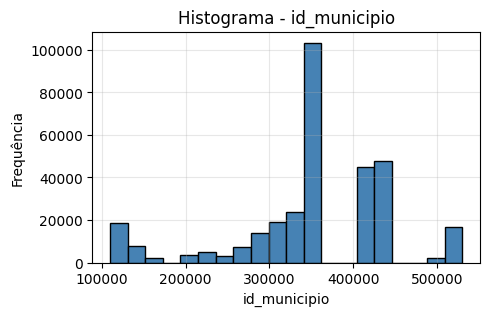

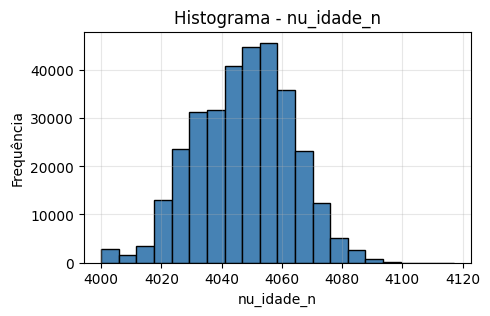

cs_sexo


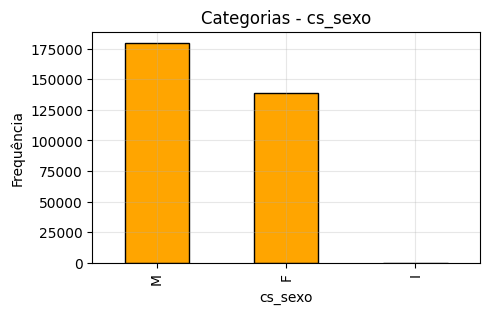

cs_gestant


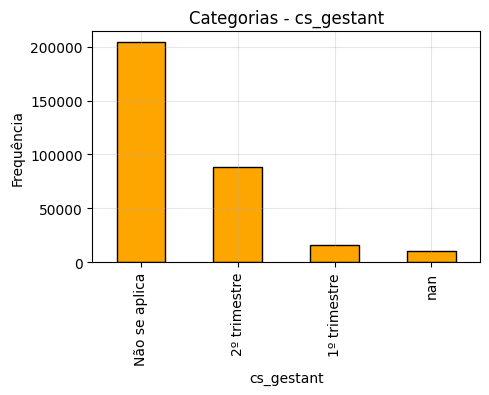

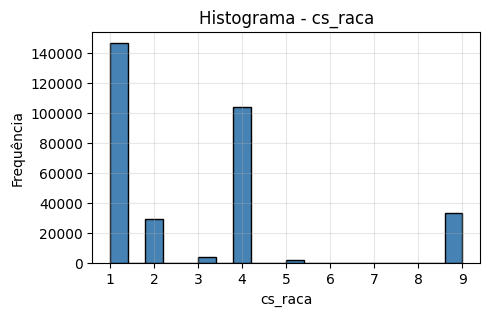

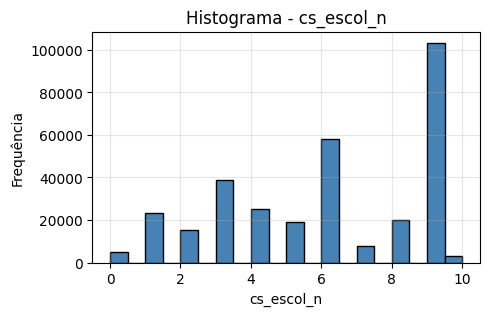

sg_uf


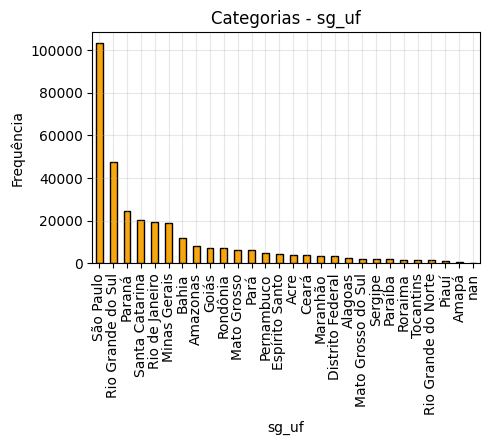

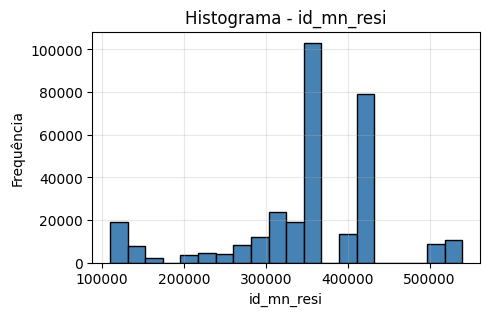

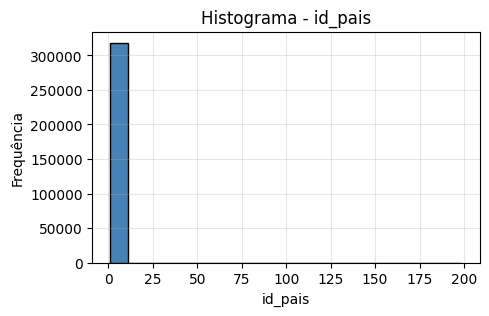

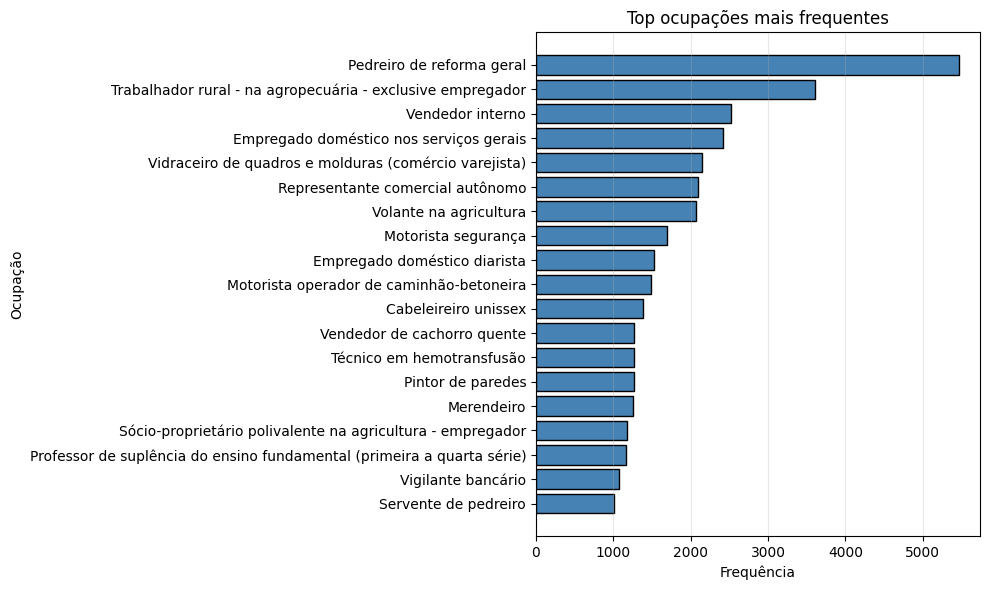

classi_fin


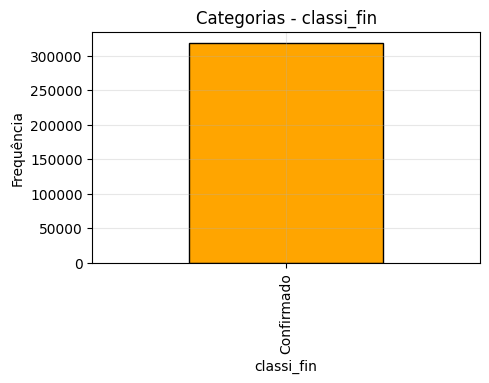

bancosangu


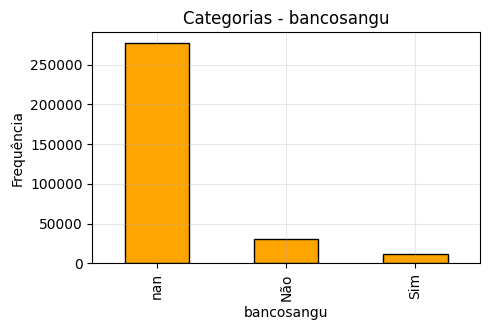

coletamarc


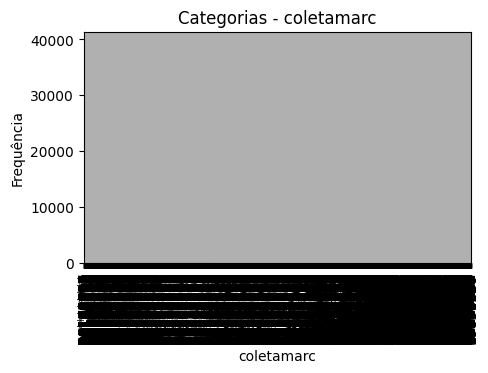

fonte


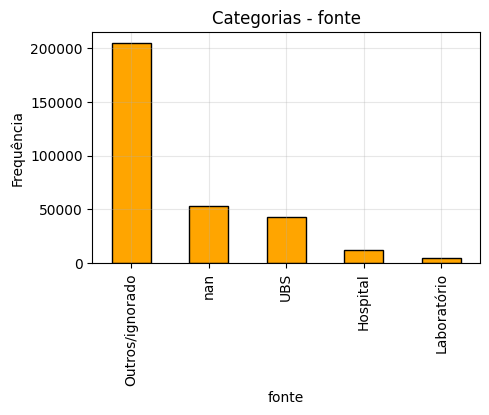

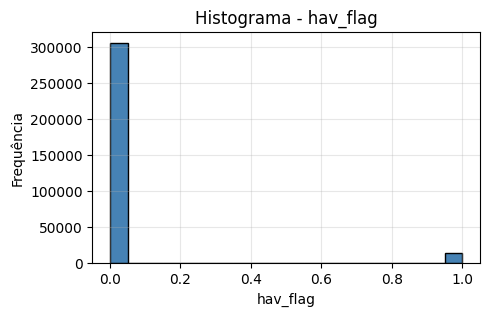

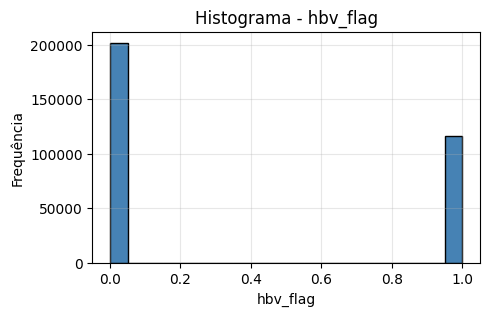

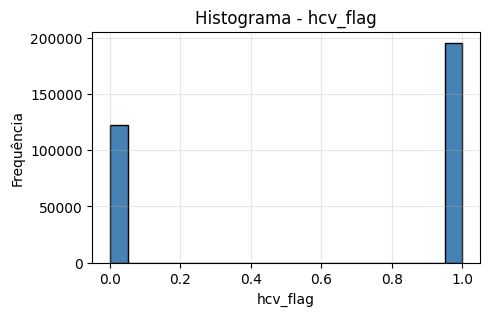

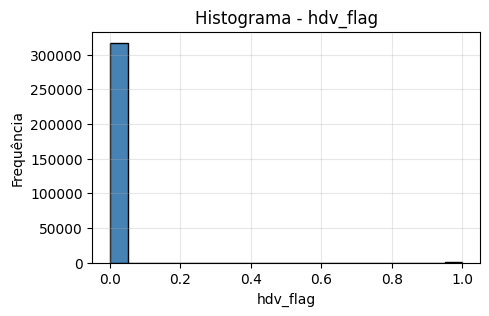

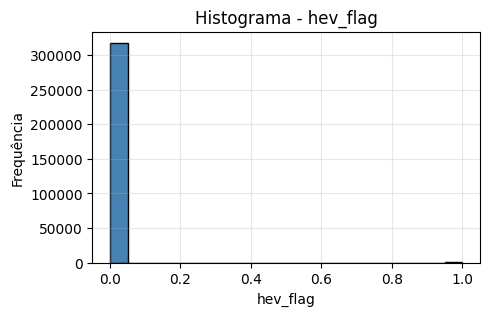

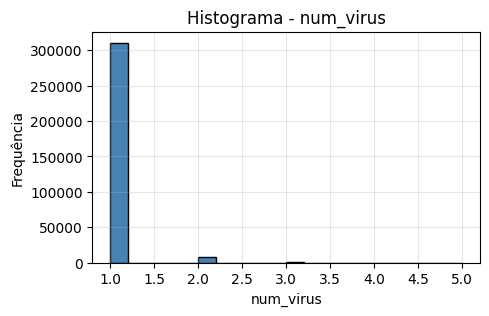

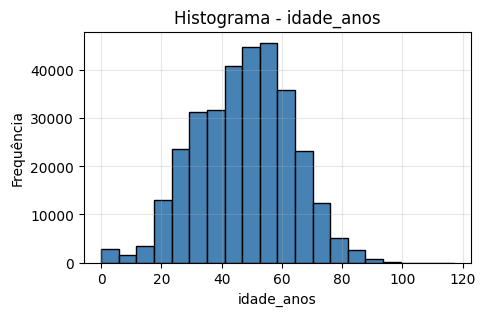

faixa_etaria


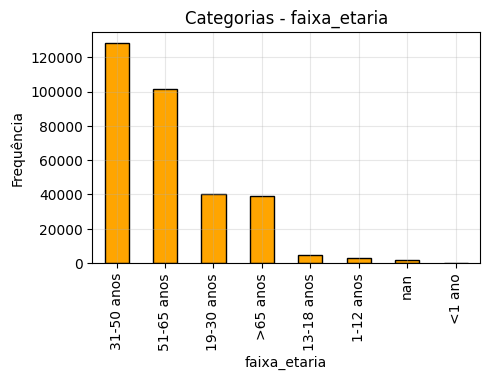

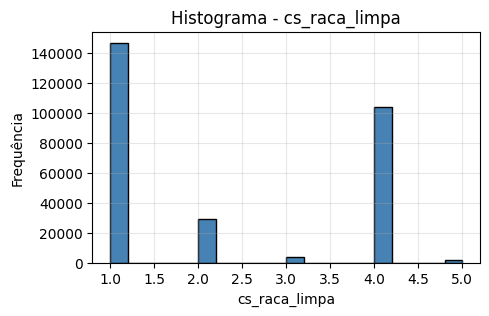

forma_valida


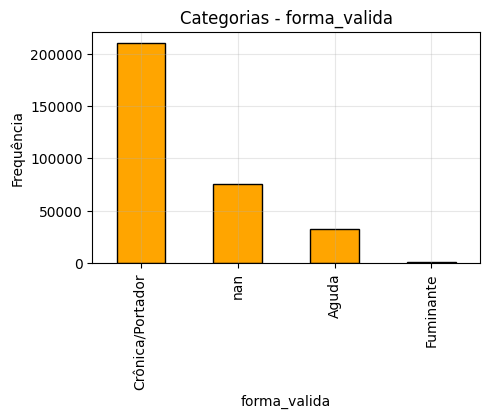

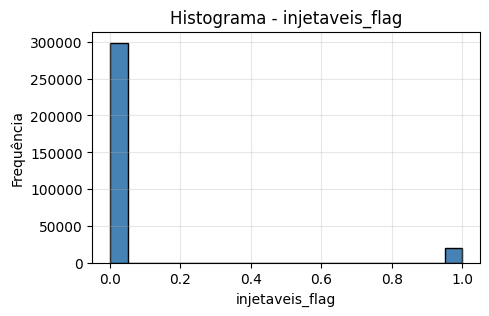

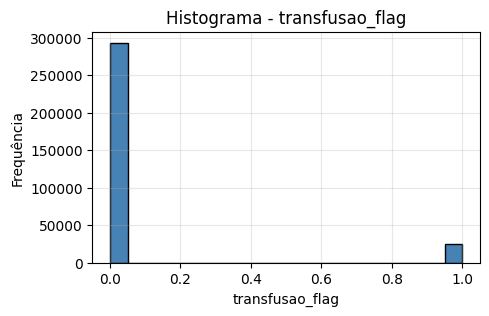

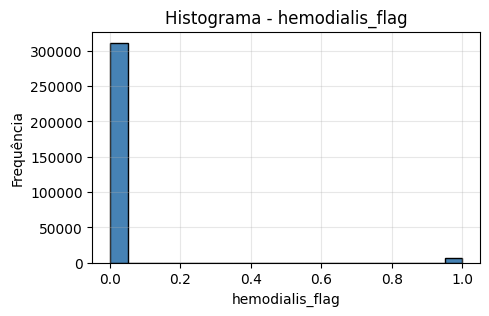

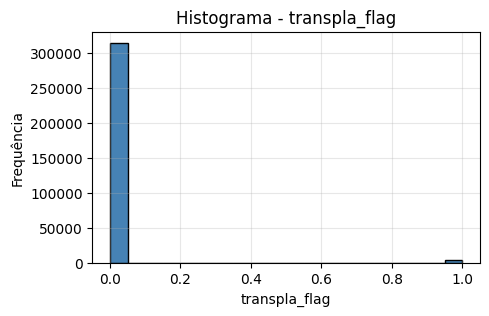

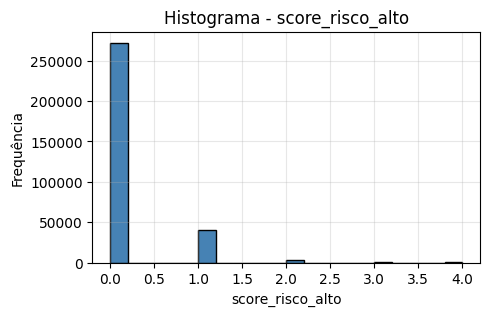

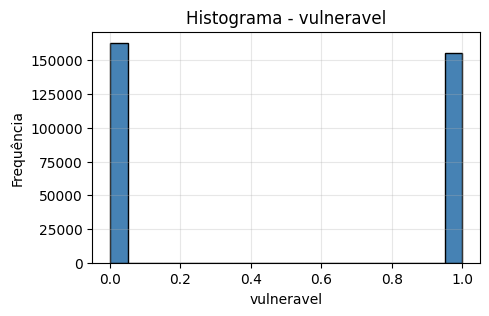

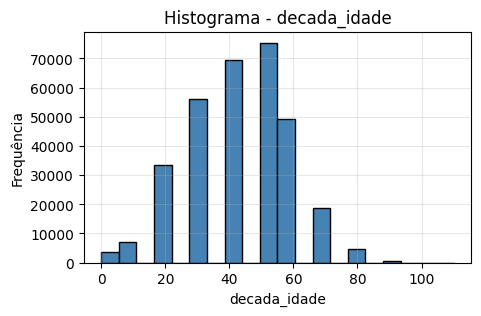

antihavigm_desc


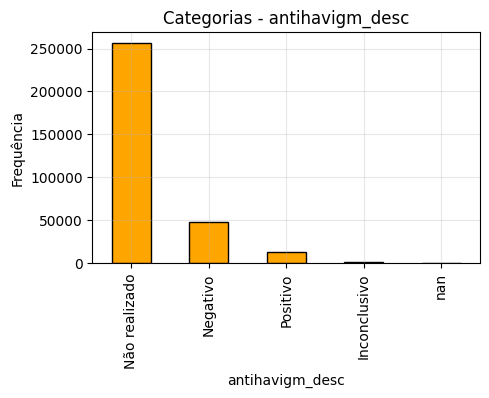

antihbs_desc


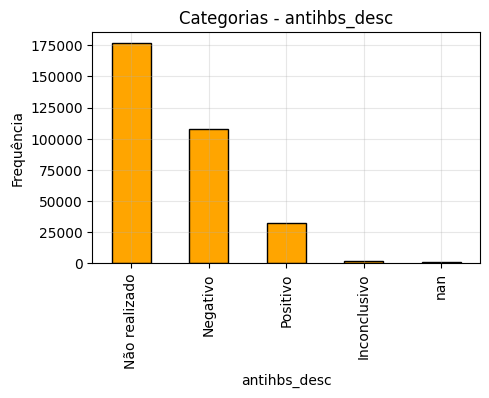

antihdvigm_desc


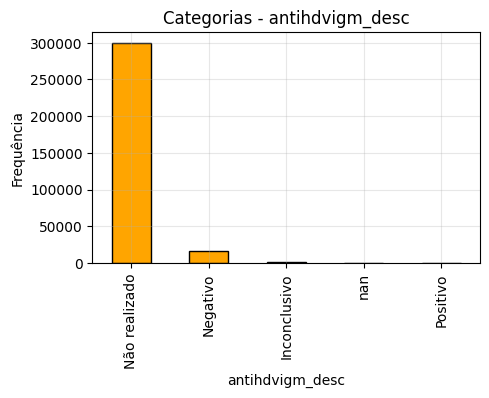

aghbs_desc


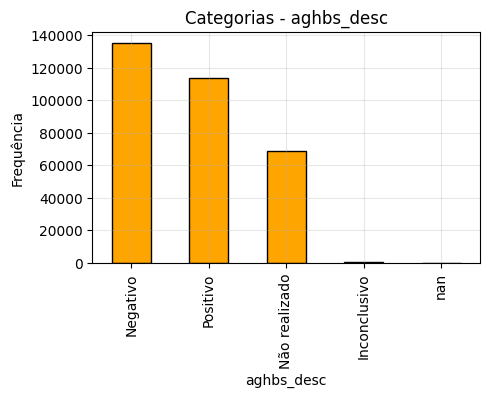

aghbe_desc


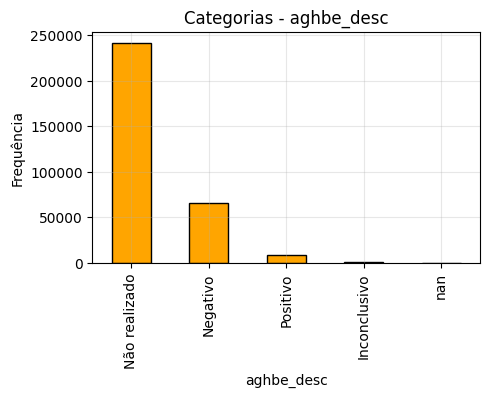

antihevigm_desc


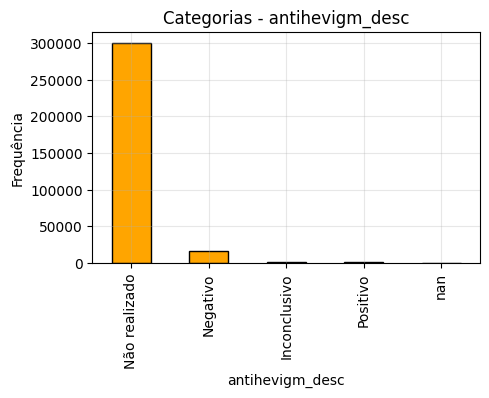

antihbcigm_desc


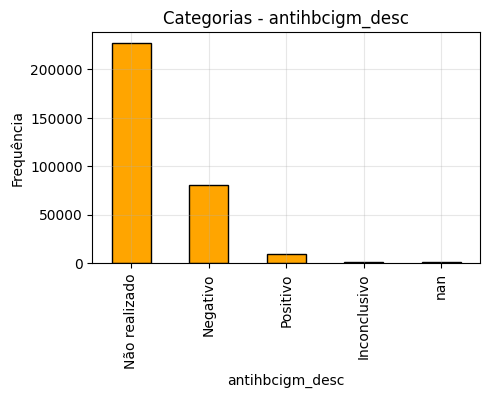

antihbe_desc


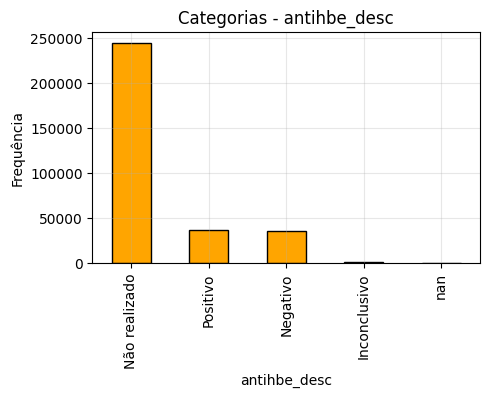

antihcv_desc


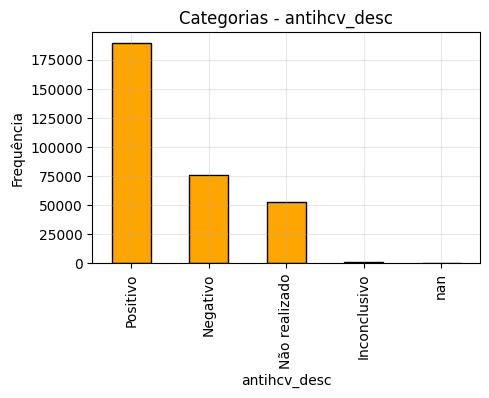

hbc_total_desc


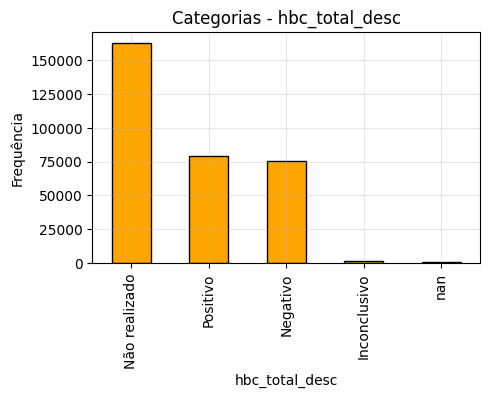

antihdv_desc


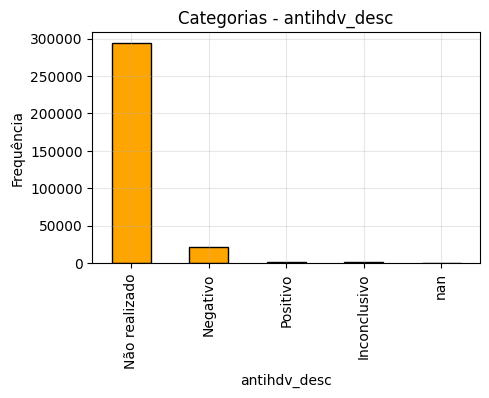

tp_sorohcv_desc


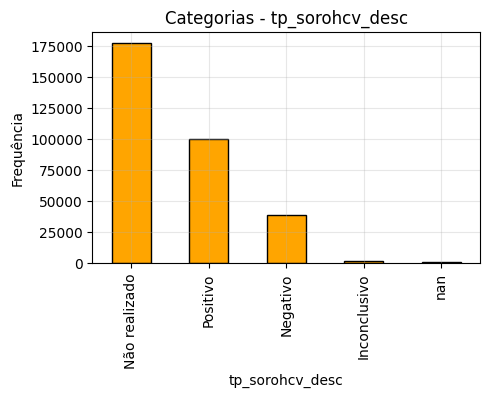

gen_vhc_desc


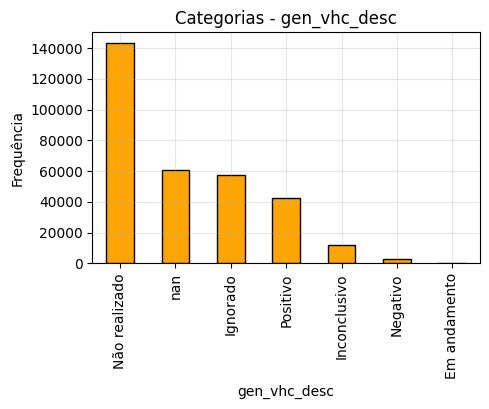

coletamarc_desc


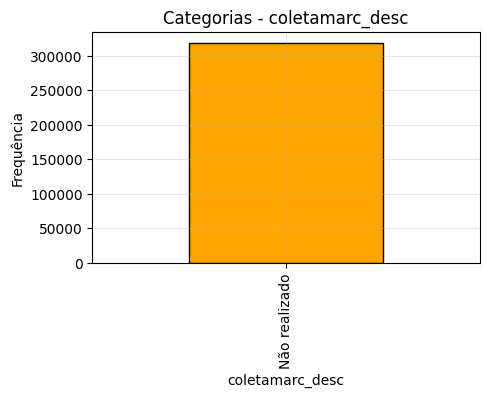

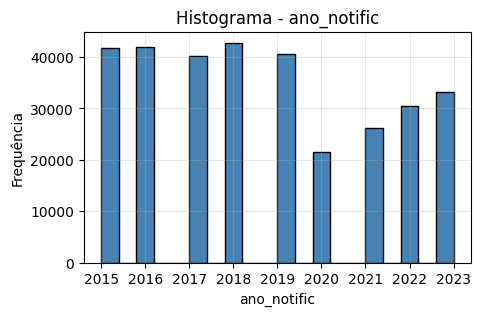

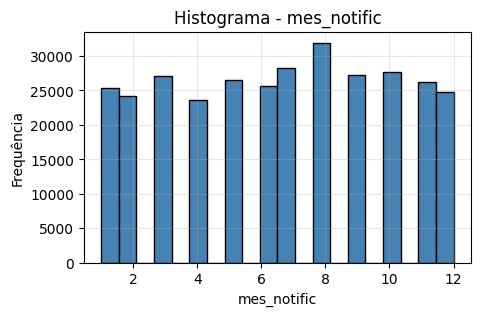

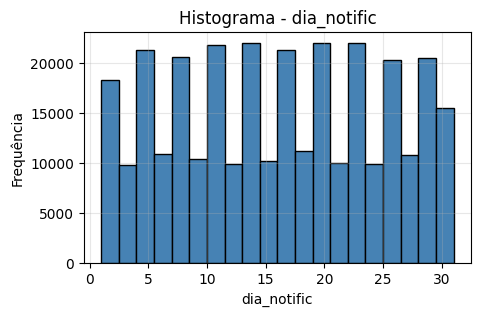

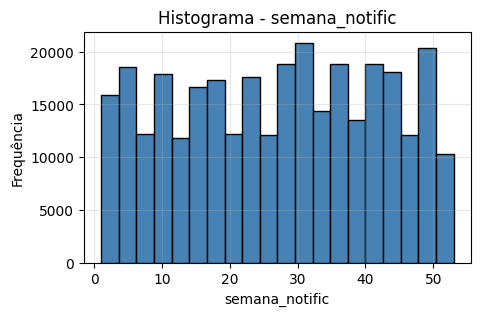

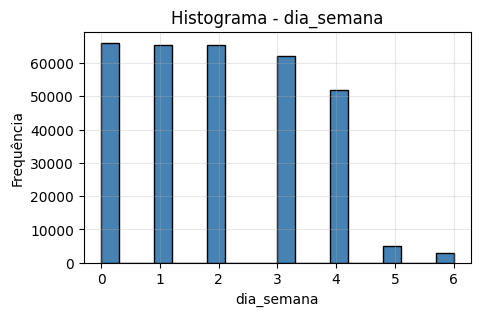

nome_dia_semana


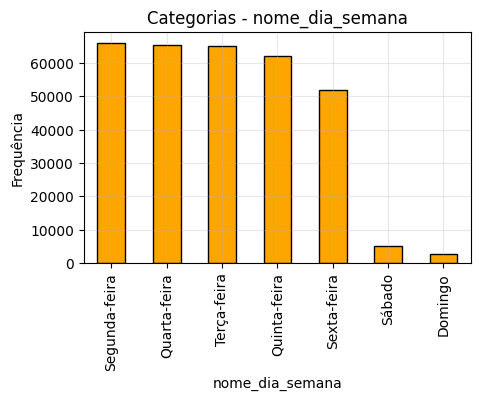

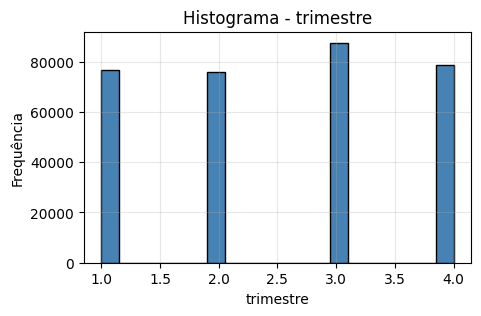

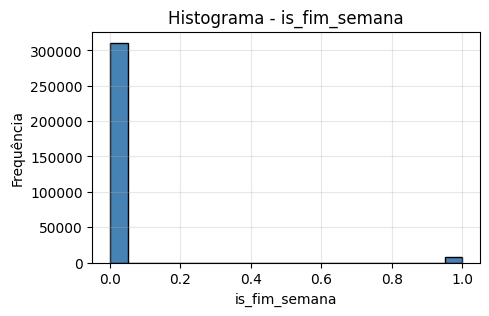

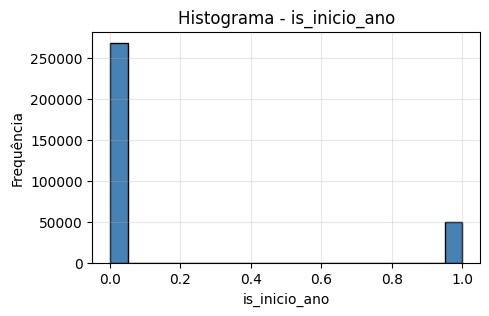

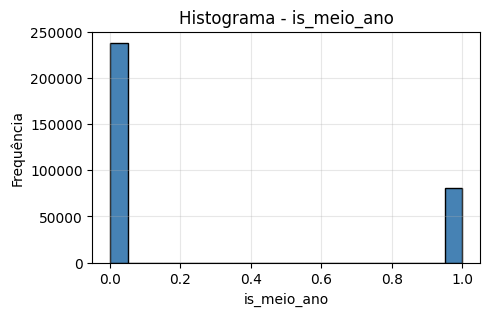

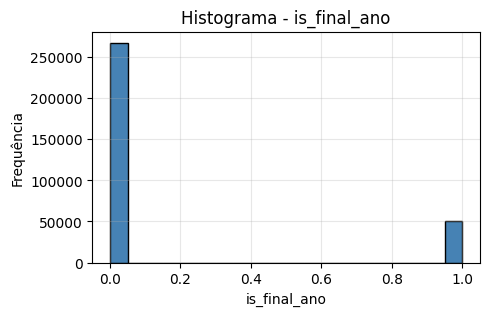

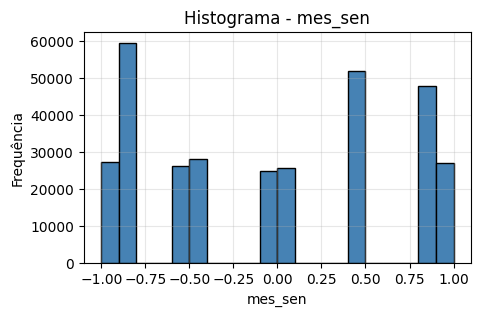

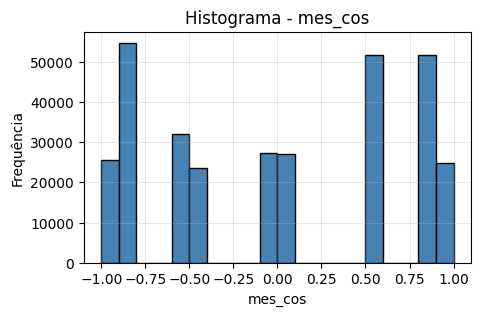

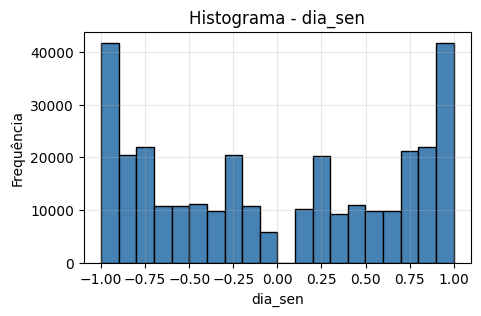

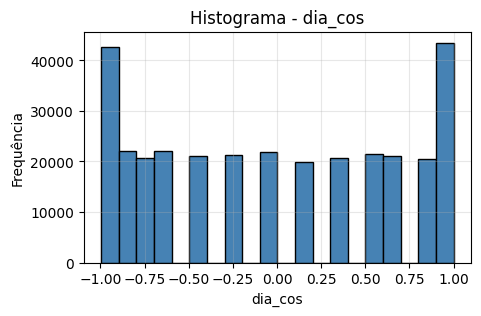

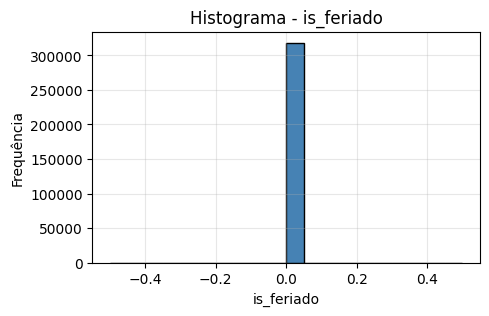

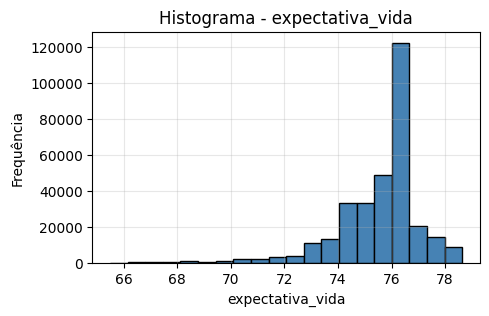

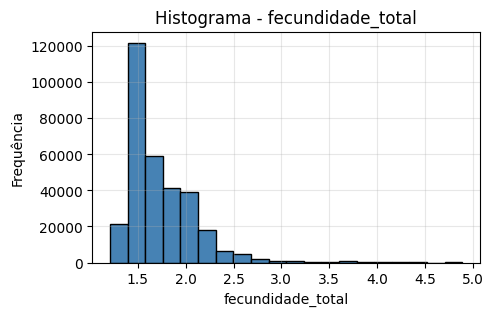

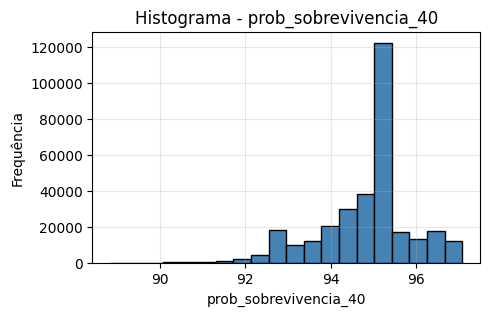

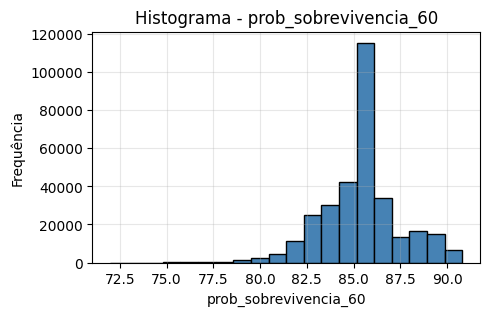

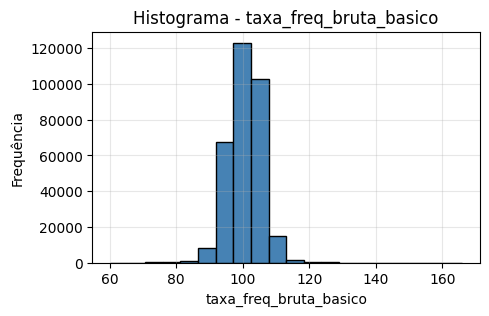

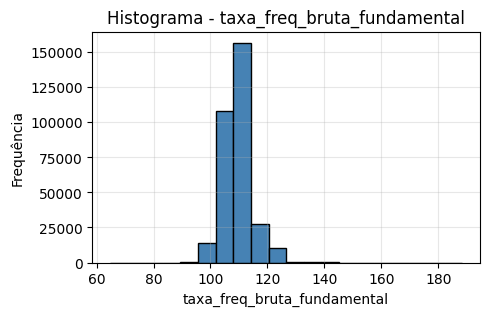

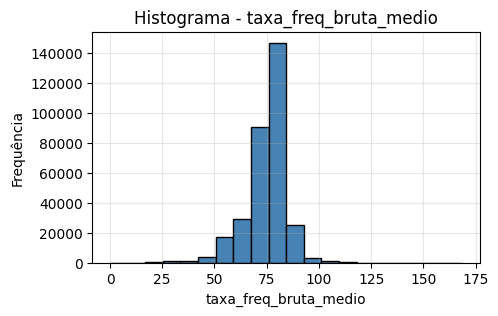

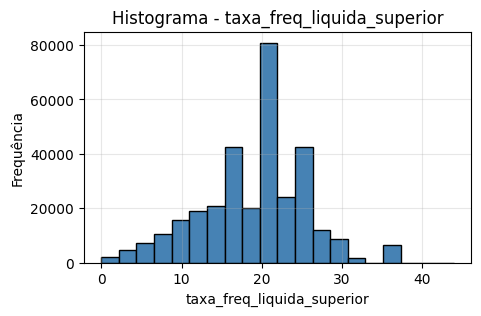

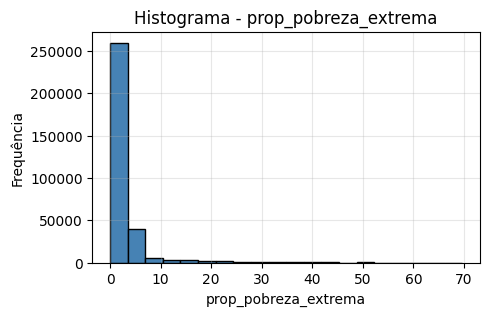

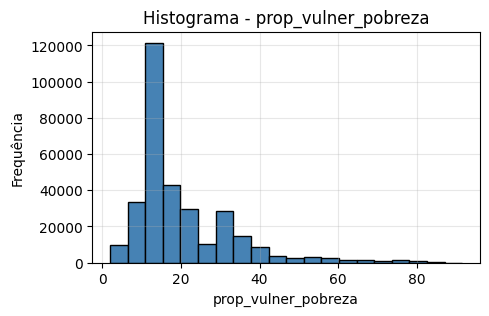

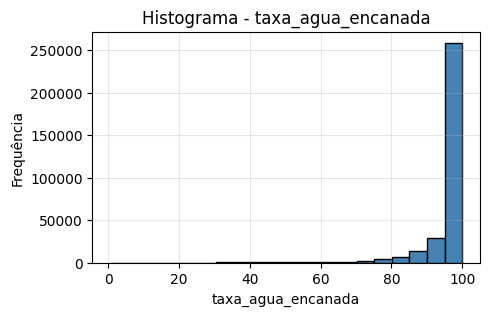

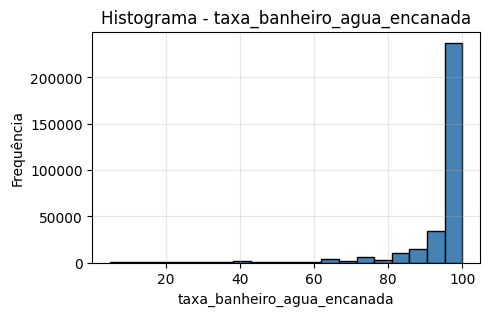

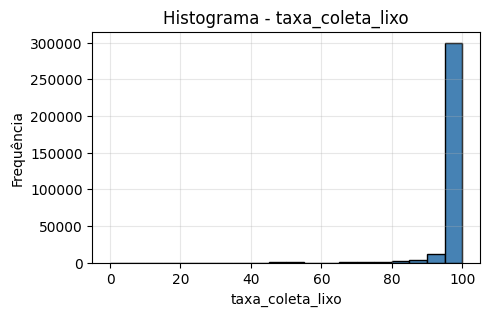

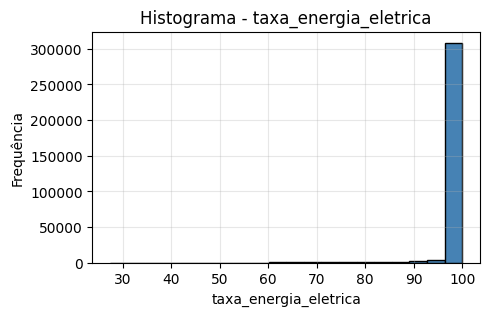

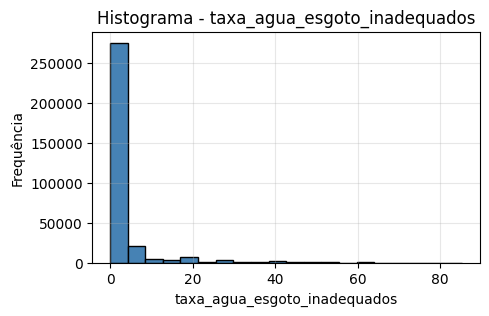

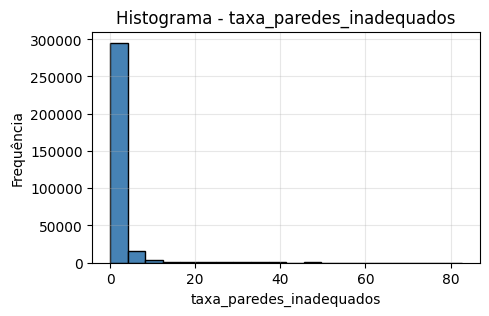

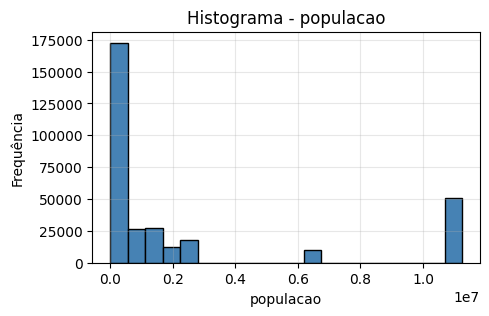

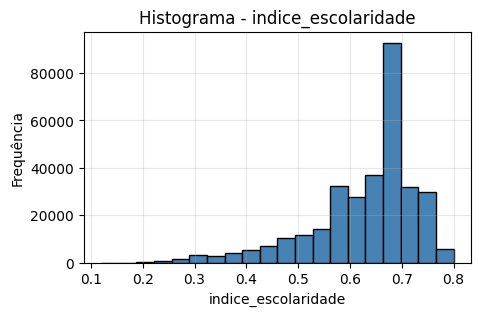

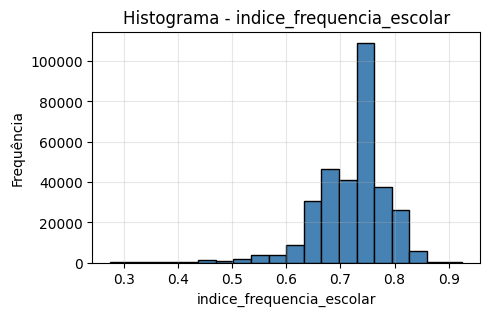

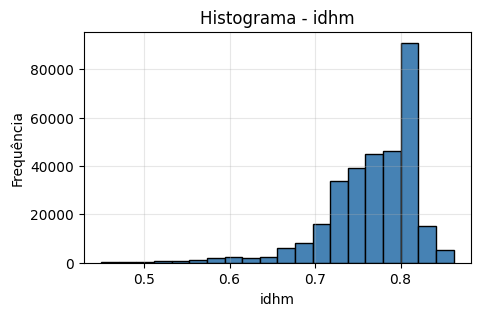

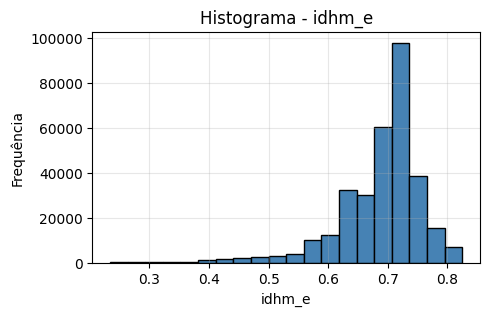

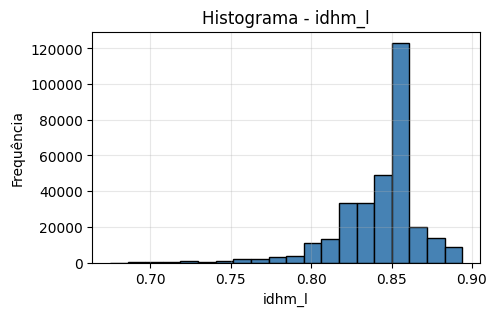

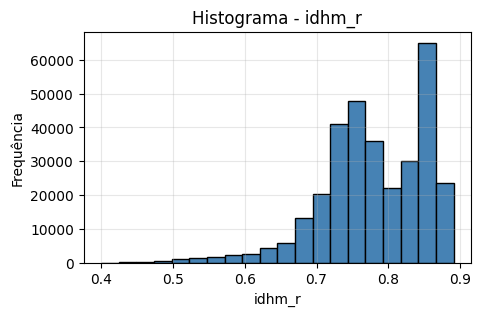

,tipo,n,média,mediana,mínimo,máximo,desvio_padrão,n_categorias,categorias
id_municipio,numérica,318586.0,350304.102268,355030.0,110001.0,530010.0,92510.880178,NaN,NaN
nu_idade_n,numérica,318586.0,4047.344444,4048.0,4000.0,4117.0,15.821768,NaN,NaN
cs_sexo,categórica,NaN,NaN,NaN,NaN,NaN,NaN,3,"{'M': 179859, 'F': 138603, 'I': 124}"
cs_gestant,categórica,NaN,NaN,NaN,NaN,NaN,NaN,4,"{'Não se aplica': 203937, '2º trimestre': 8811..."
cs_raca,numérica,318586.0,2.948965,2.0,1.0,9.0,2.457592,NaN,NaN
...,...,...,...,...,...,...,...,...,...
indice_frequencia_escolar,numérica,318586.0,0.723424,0.748,0.275,0.925,0.063543,NaN,NaN
idhm,numérica,318586.0,0.766661,0.778,0.45,0.862,0.05229,NaN,NaN
idhm_e,numérica,318586.0,0.688801,0.705,0.234,0.825,0.068244,NaN,NaN
idhm_l,numérica,318586.0,0.843446,0.852,0.675,0.894,0.024925,NaN,NaN


In [11]:
resumo_dataframe(df_EDA)

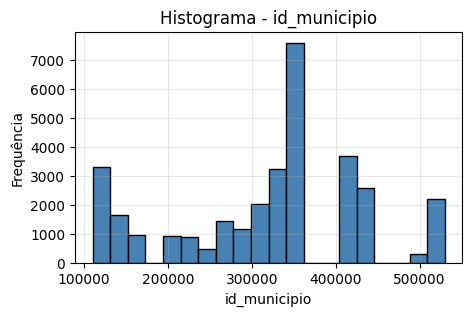

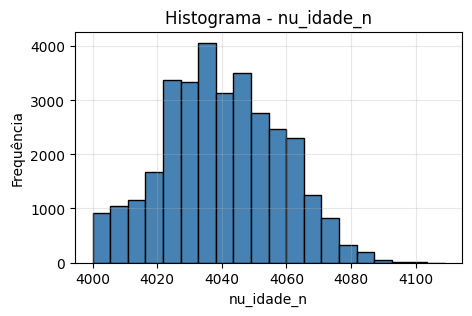

cs_sexo


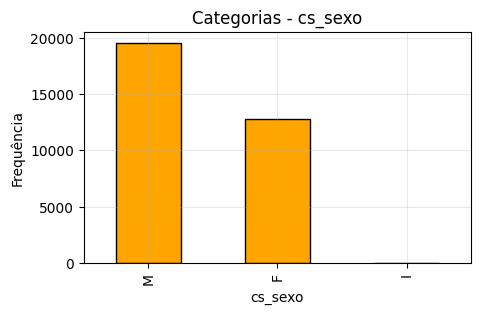

cs_gestant


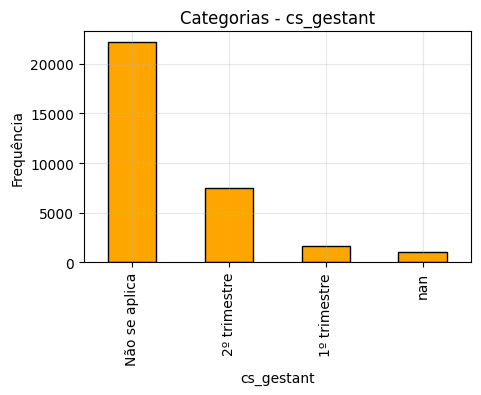

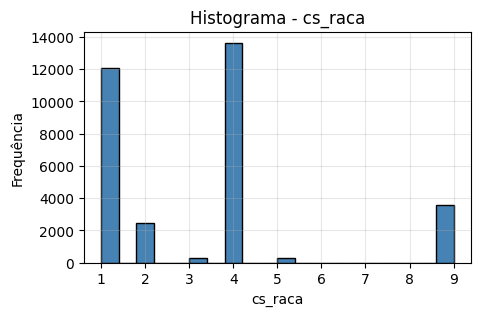

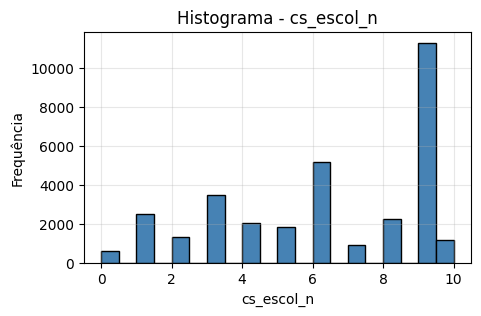

sg_uf


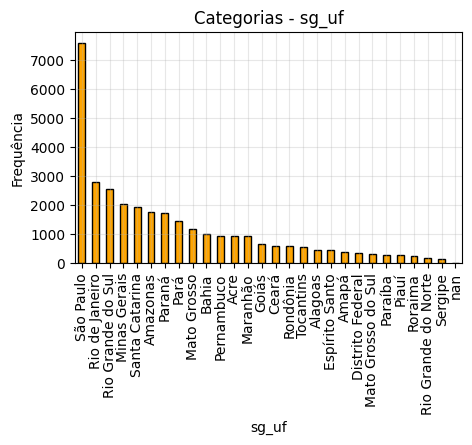

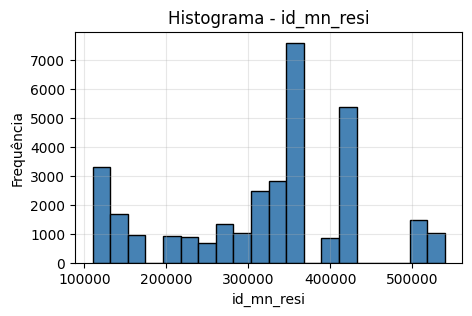

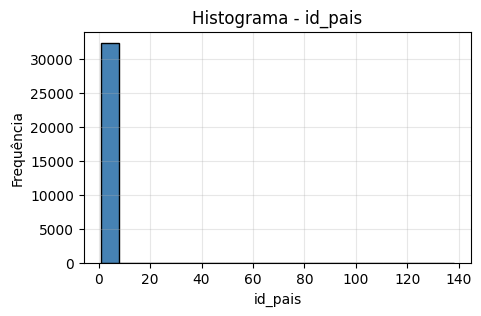

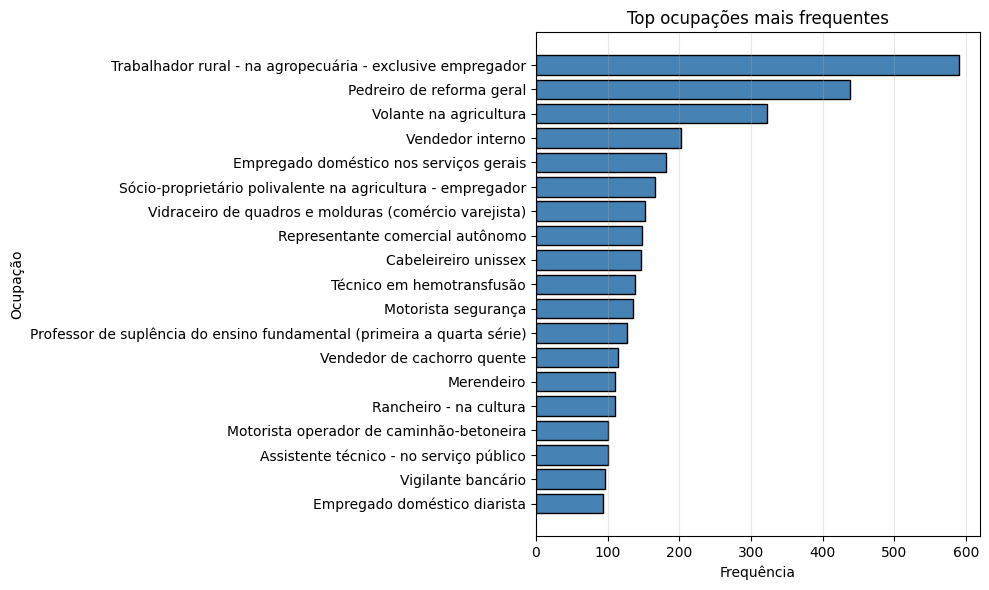

classi_fin


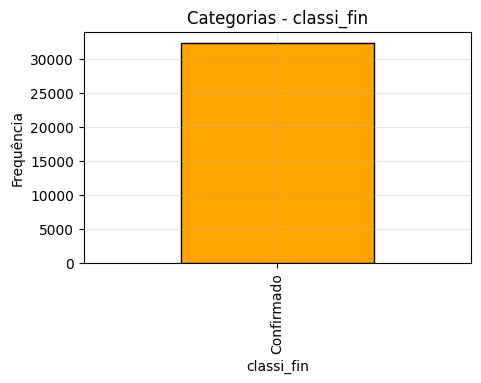

bancosangu


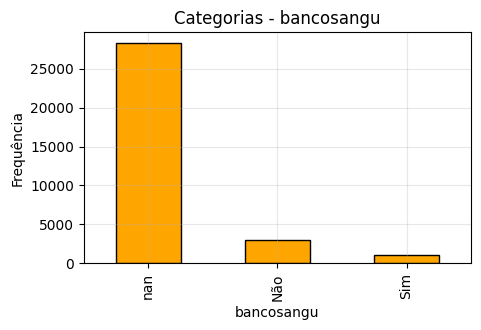

coletamarc


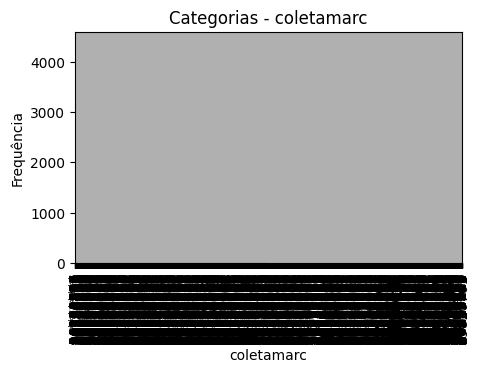

fonte


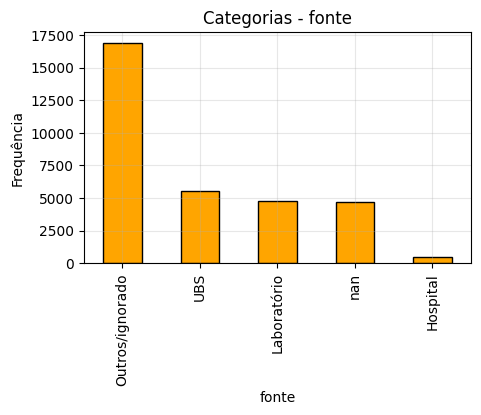

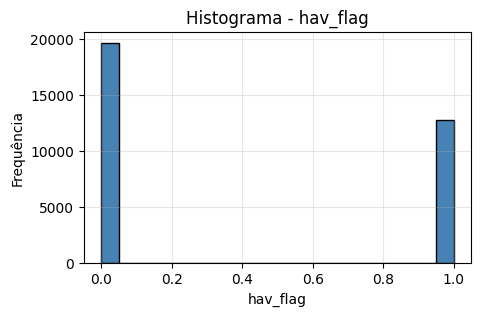

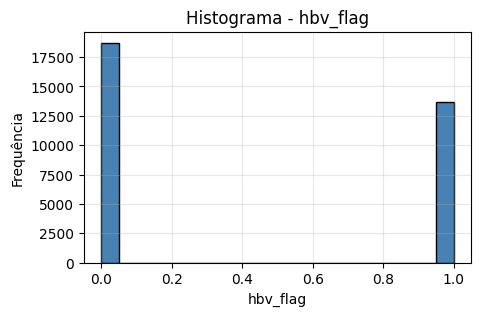

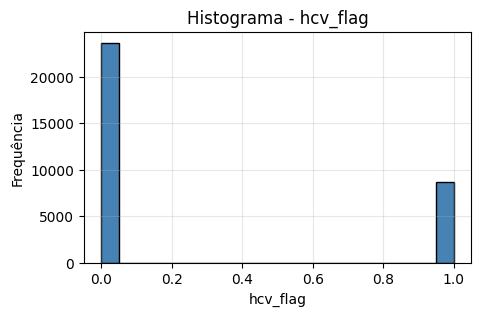

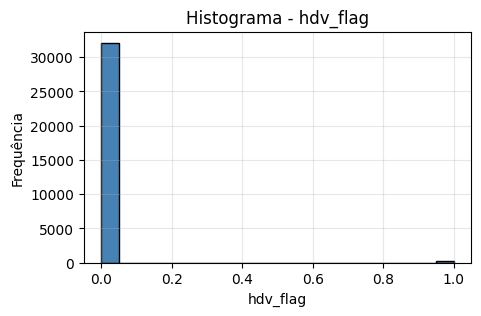

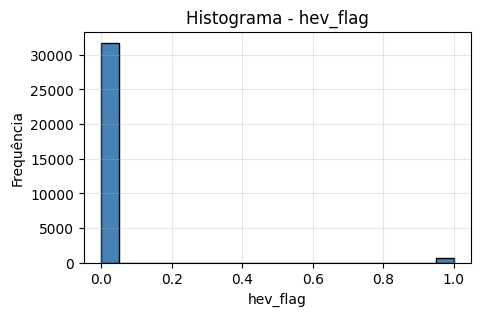

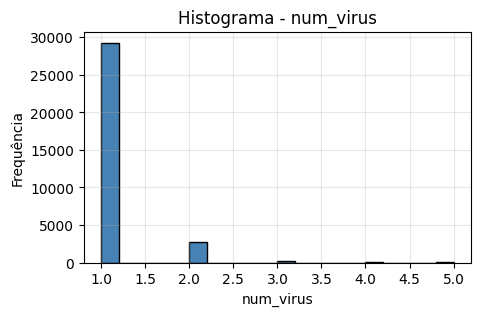

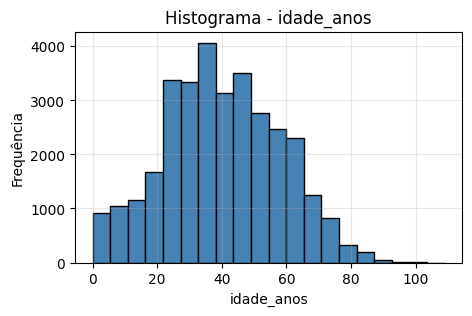

faixa_etaria


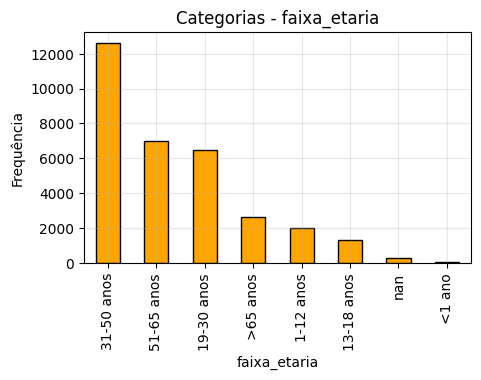

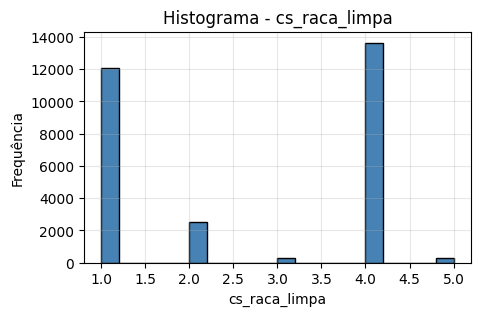

forma_valida


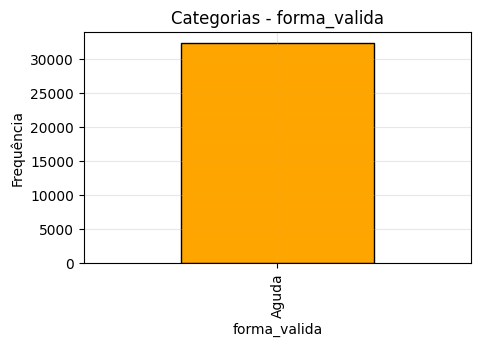

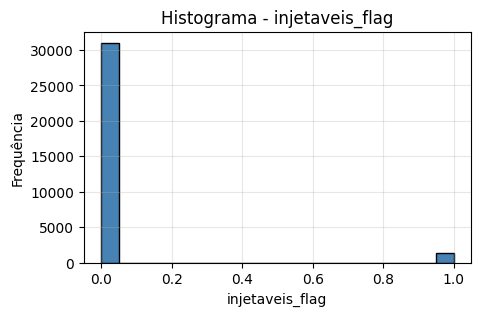

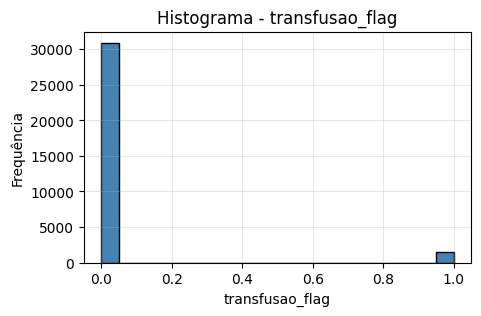

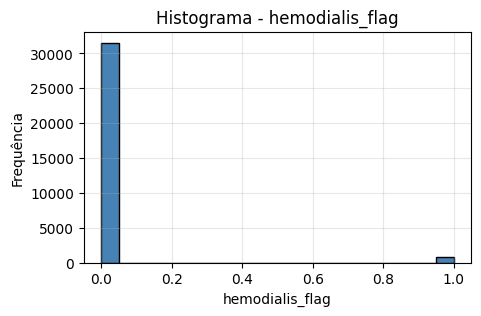

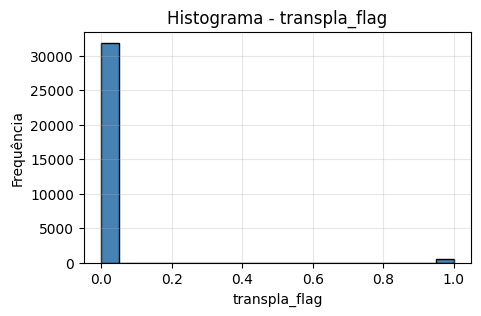

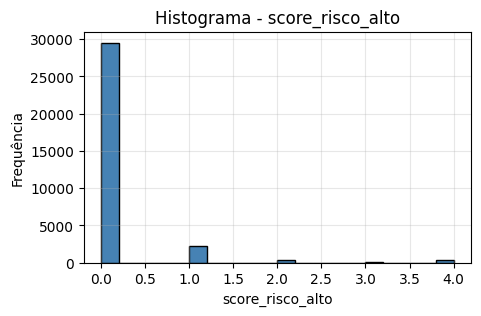

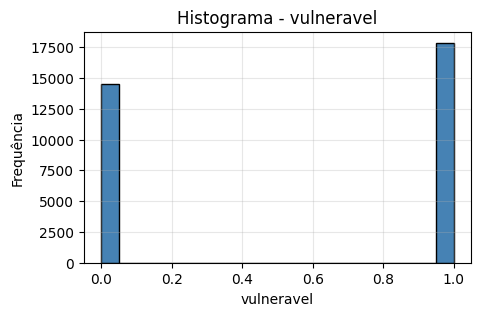

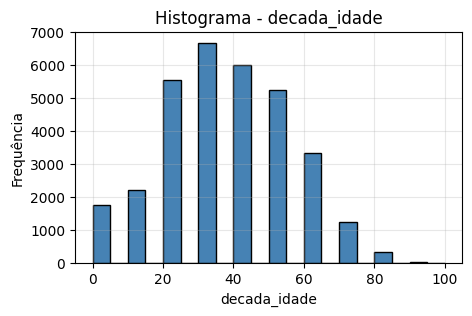

antihavigm_desc


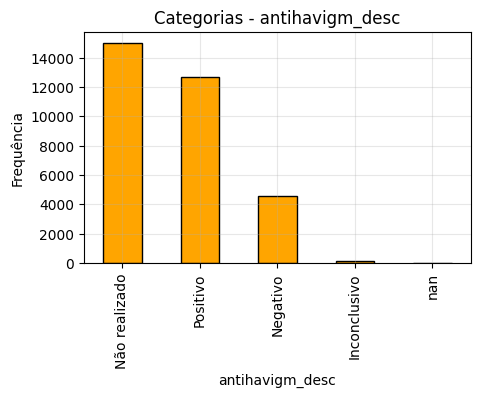

antihbs_desc


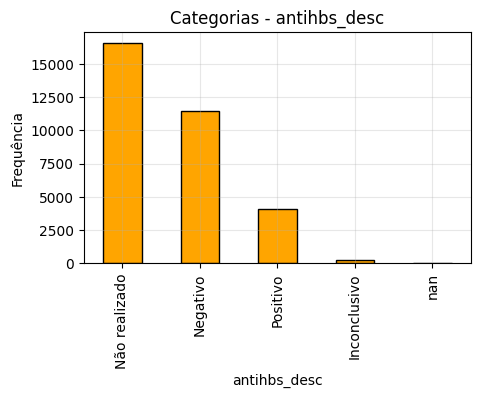

antihdvigm_desc


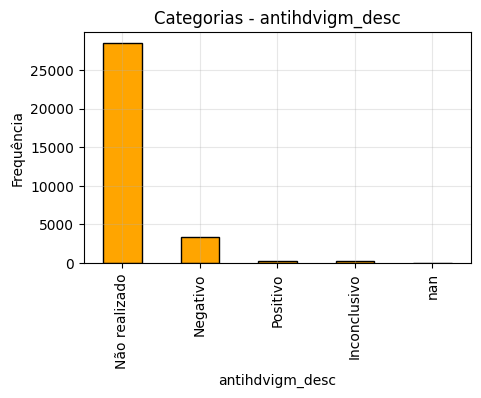

aghbs_desc


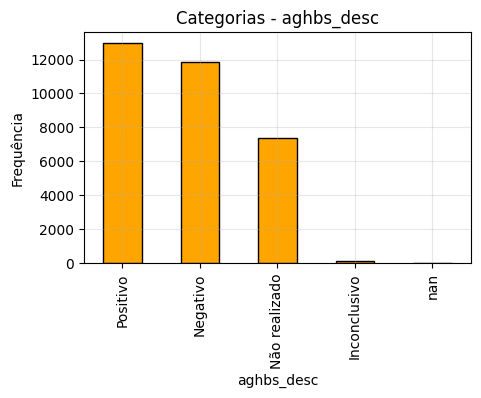

aghbe_desc


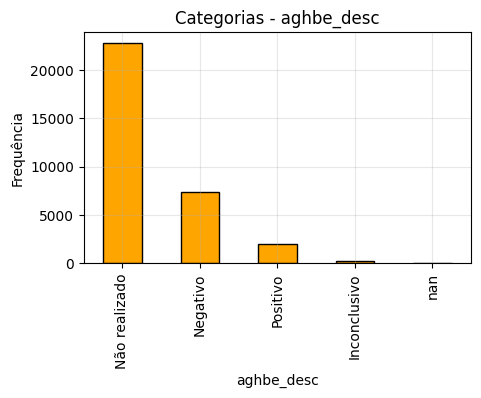

antihevigm_desc


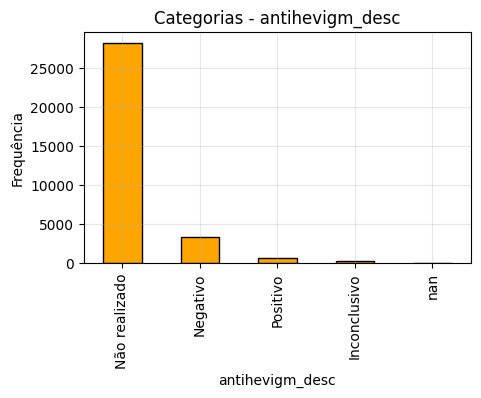

antihbcigm_desc


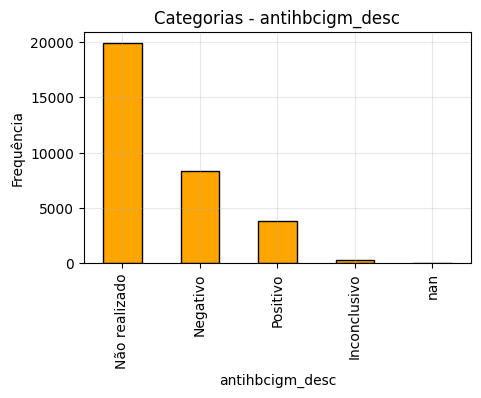

antihbe_desc


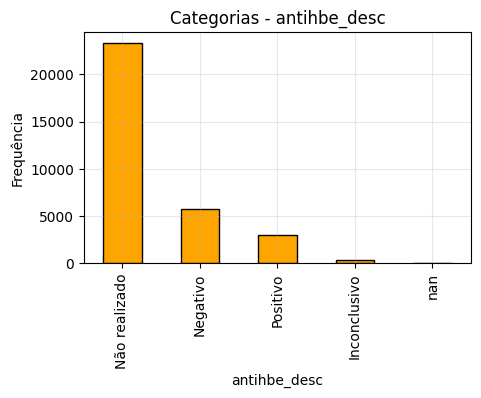

antihcv_desc


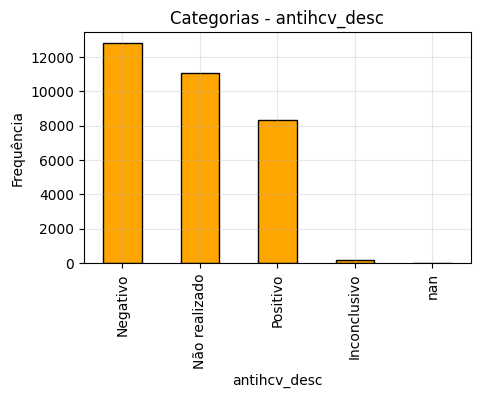

hbc_total_desc


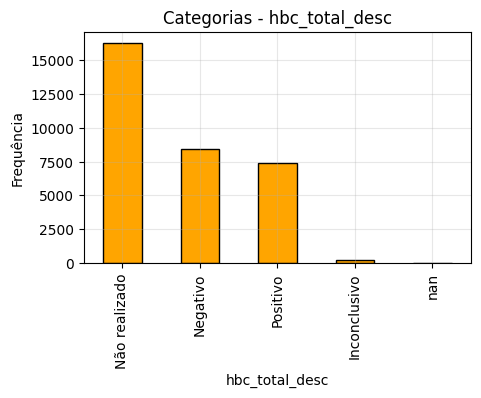

antihdv_desc


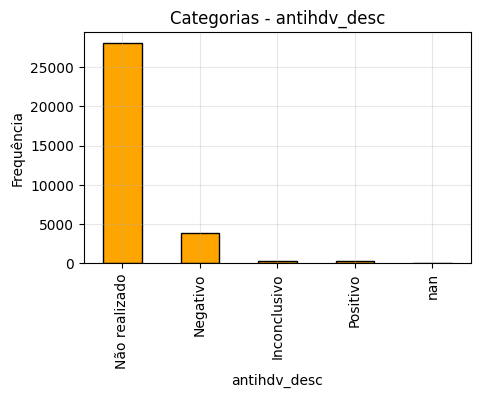

tp_sorohcv_desc


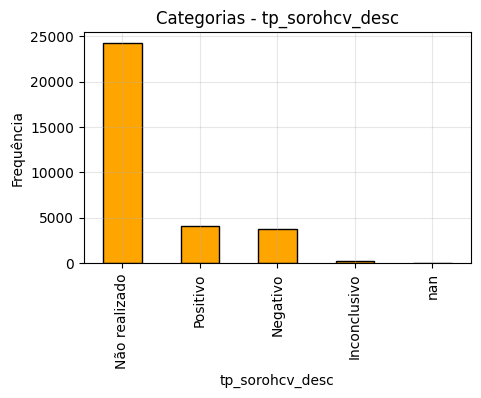

gen_vhc_desc


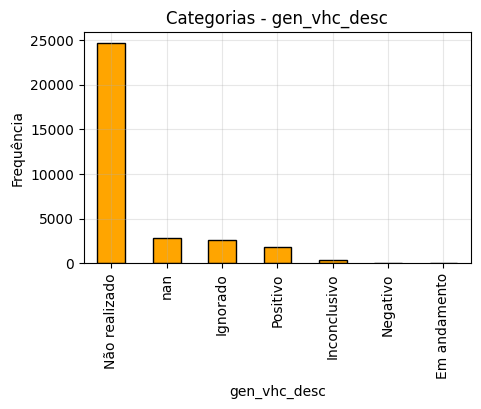

coletamarc_desc


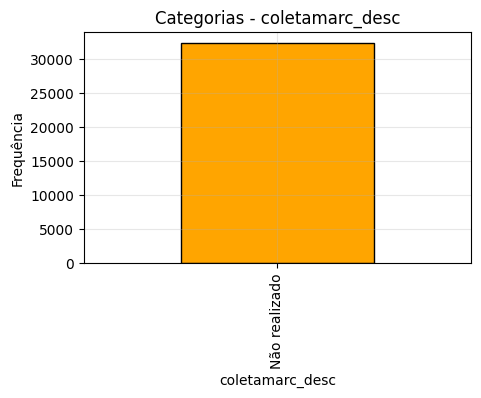

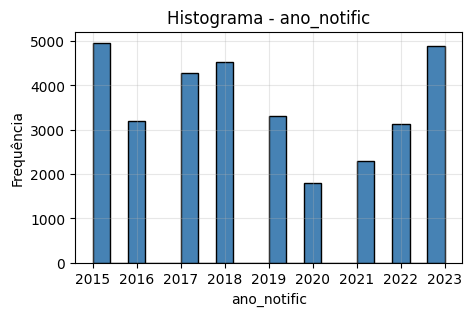

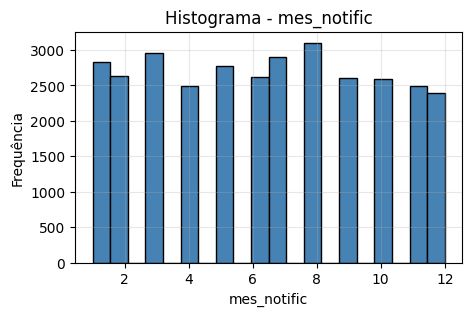

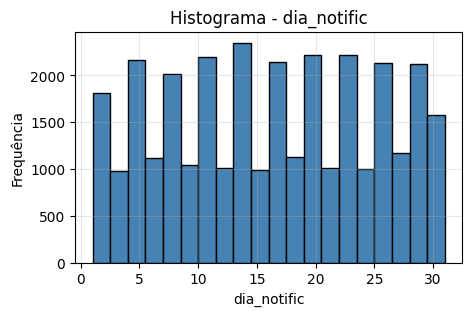

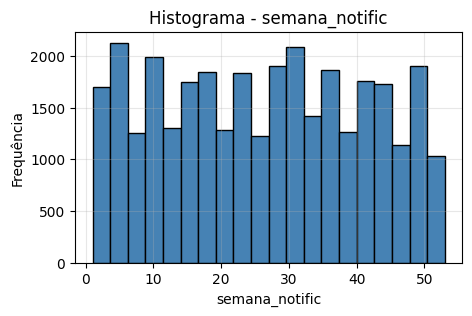

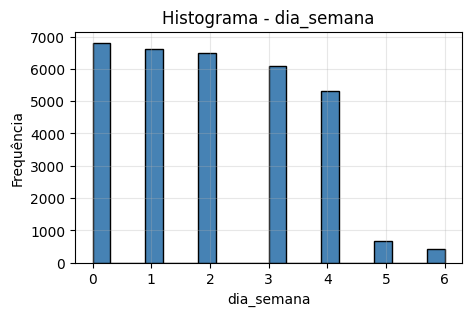

nome_dia_semana


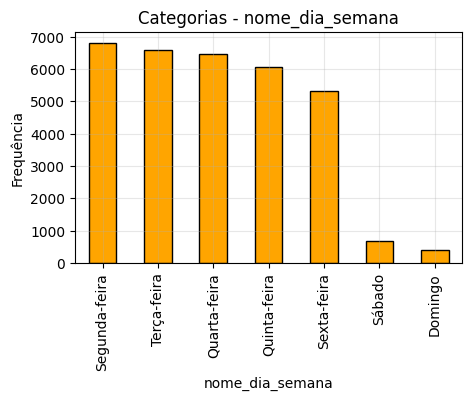

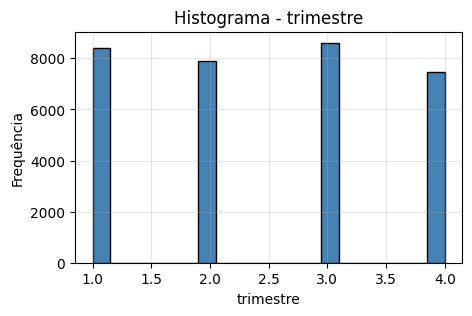

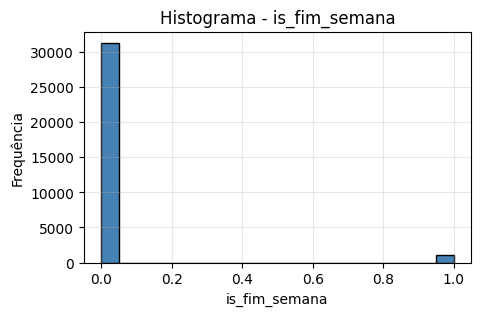

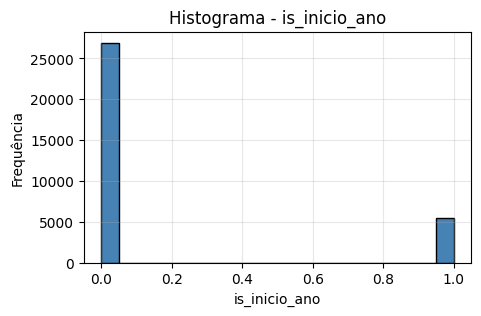

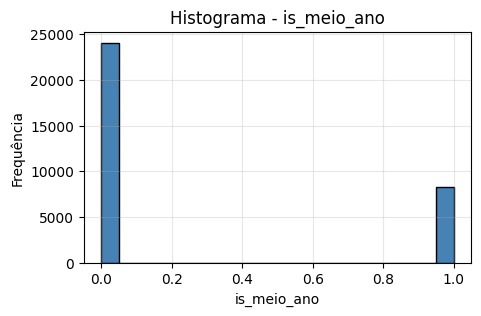

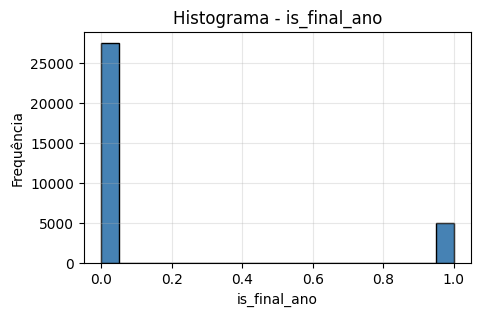

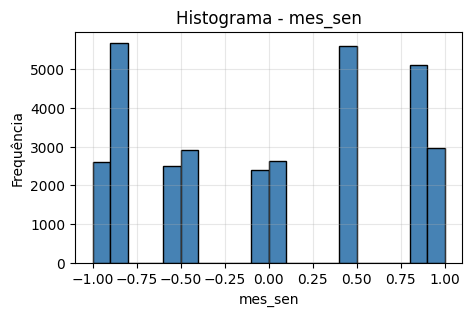

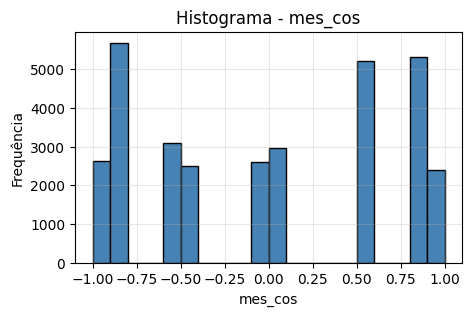

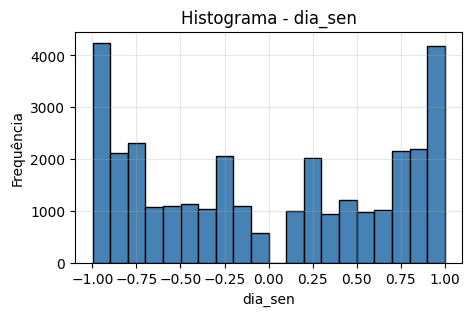

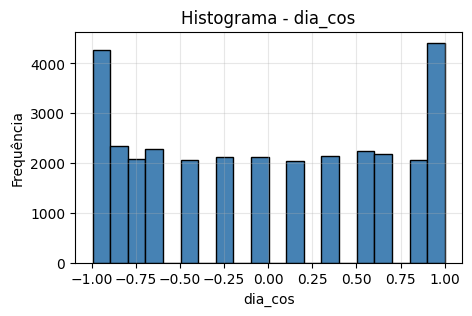

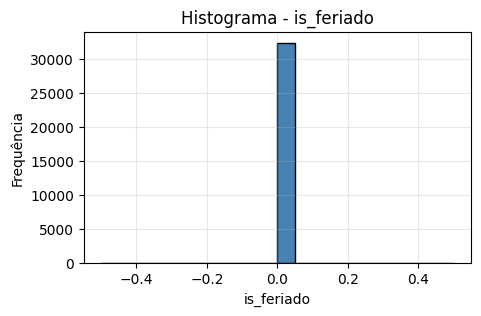

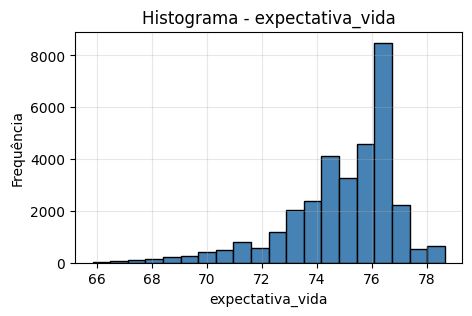

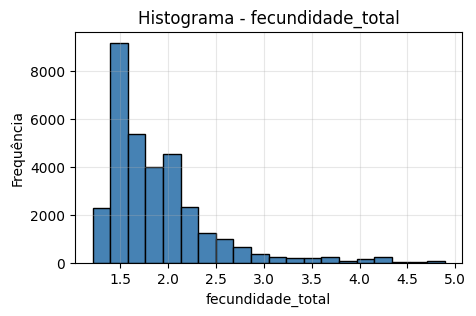

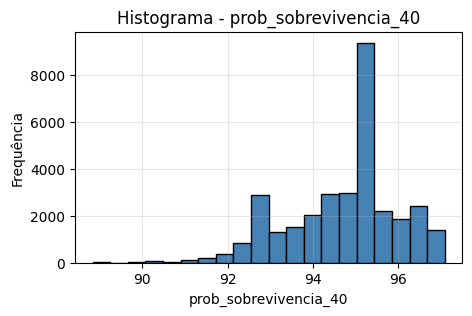

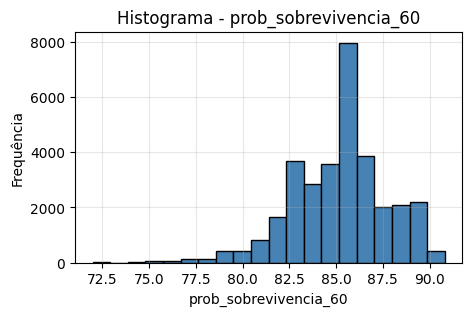

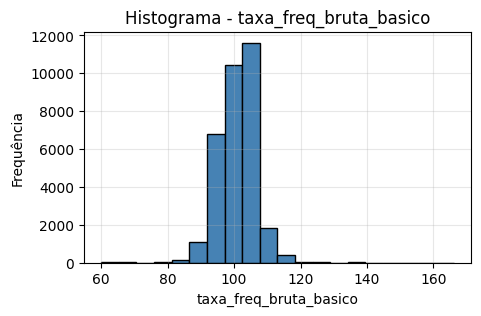

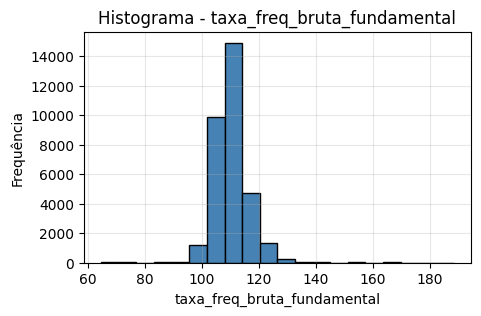

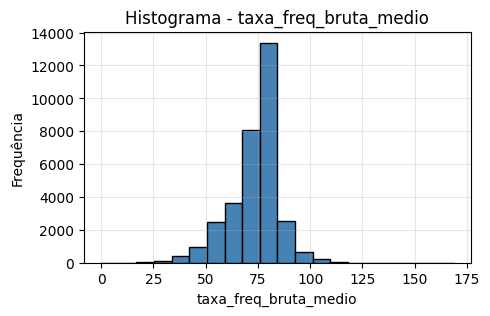

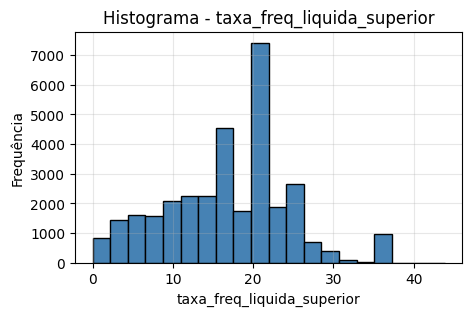

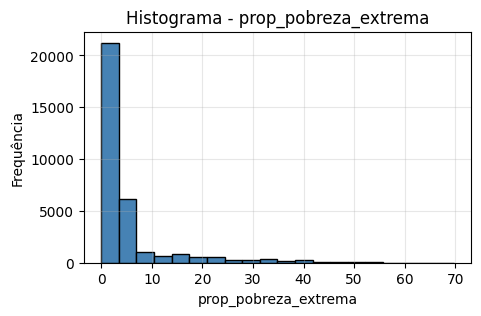

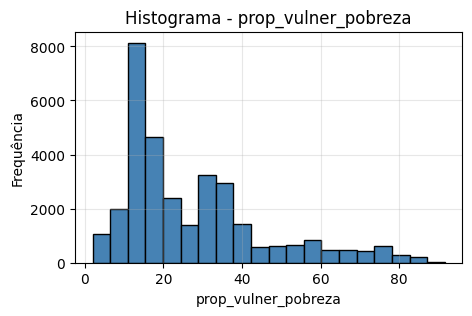

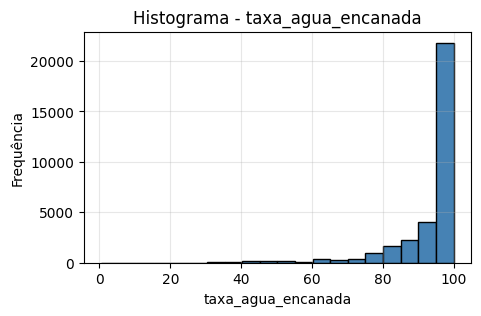

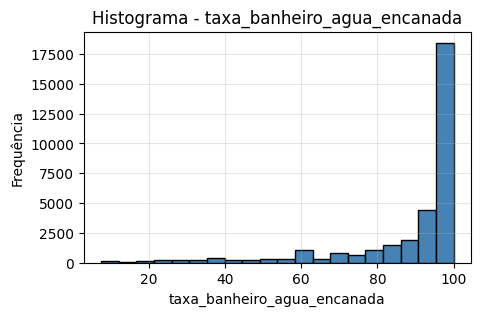

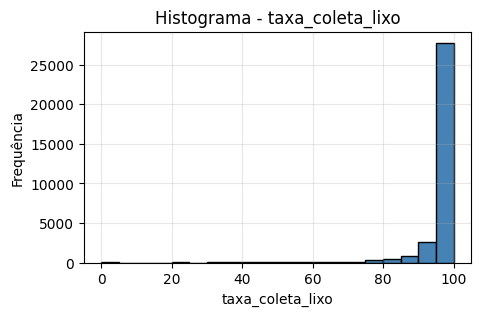

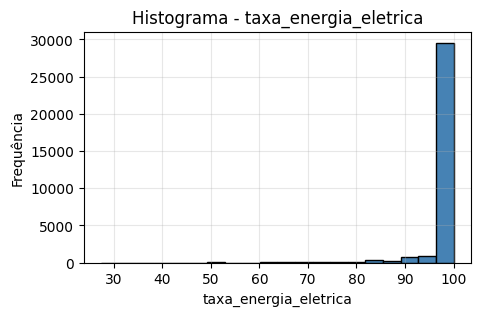

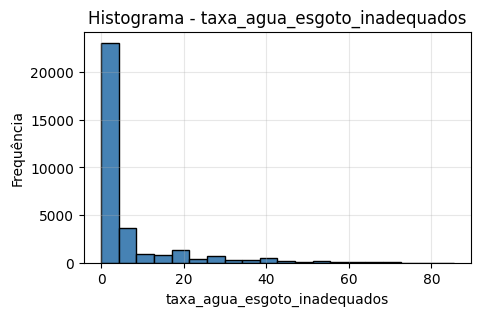

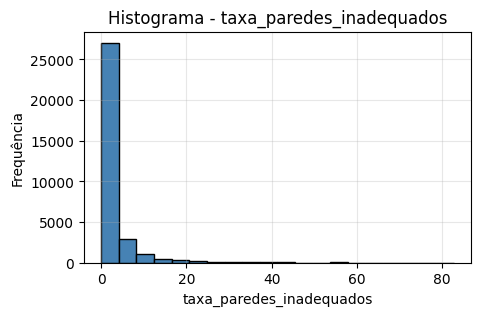

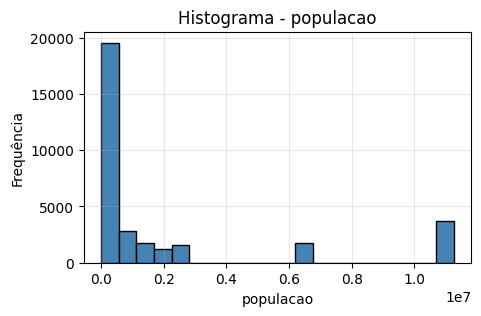

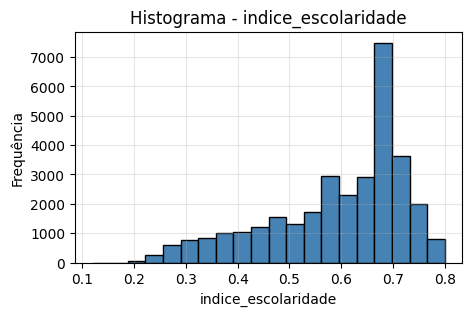

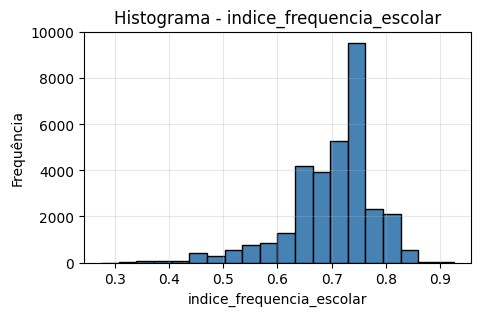

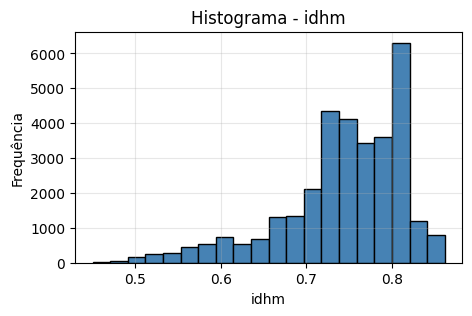

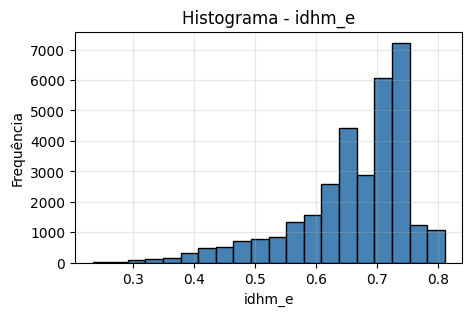

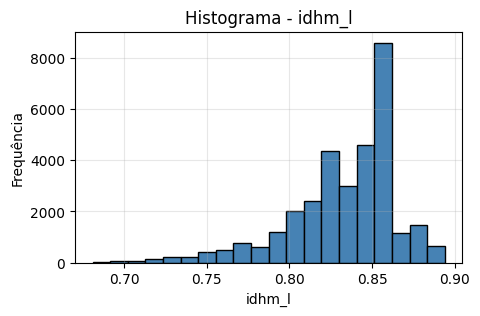

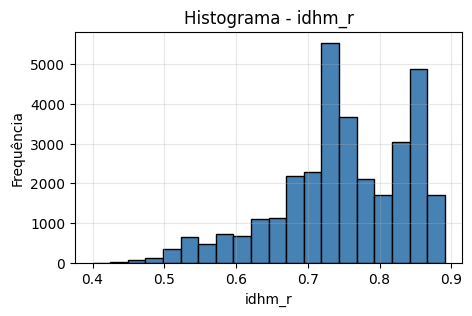

,tipo,n,média,mediana,mínimo,máximo,desvio_padrão,n_categorias,categorias
id_municipio,numérica,32382.0,319912.975758,350470.0,110001.0,530010.0,110550.984268,NaN,NaN
nu_idade_n,numérica,32382.0,4040.068186,4040.0,4000.0,4109.0,17.971646,NaN,NaN
cs_sexo,categórica,NaN,NaN,NaN,NaN,NaN,NaN,3,"{'M': 19583, 'F': 12793, 'I': 6}"
cs_gestant,categórica,NaN,NaN,NaN,NaN,NaN,NaN,4,"{'Não se aplica': 22164, '2º trimestre': 7517,..."
cs_raca,numérica,32382.0,3.282935,4.0,1.0,9.0,2.440837,NaN,NaN
...,...,...,...,...,...,...,...,...,...
indice_frequencia_escolar,numérica,32382.0,0.702857,0.717,0.275,0.925,0.080209,NaN,NaN
idhm,numérica,32382.0,0.743328,0.754,0.45,0.862,0.071415,NaN,NaN
idhm_e,numérica,32382.0,0.662183,0.693,0.234,0.811,0.092226,NaN,NaN
idhm_l,numérica,32382.0,0.832273,0.842,0.681,0.894,0.03278,NaN,NaN


In [12]:
resumo_dataframe(df_EDA_Aguda)